# LSTM Training

2025-09-30 11:28:38.376074: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


SMART TRUST METER - MODEL TRAINING PIPELINE
Loading data...
Training samples: 718
Testing samples: 309

Preprocessing text...
Extracting sentiment features...
Tokenizing text...

Data preparation complete!
Text sequences shape: (718, 100)
Features shape: (718, 6)
Labels distribution - Train: [251 467], Test: [108 201]

STARTING MODEL TRAINING

Building LSTM model...

Model architecture:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None, 100)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 100, 128)             640000    ['text_input[0][0]']          
                                                                                                  
 

/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


23/23 [==============================] - ETA: 0s - loss: 0.5248 - accuracy: 0.7423 - precision: 0.7536 - recall: 0.8972
Epoch 2: val_accuracy improved from 0.65049 to 0.82201, saving model to best_trust_meter_model.h5
23/23 [==============================] - 4s 189ms/step - loss: 0.5248 - accuracy: 0.7423 - precision: 0.7536 - recall: 0.8972 - val_loss: 0.4394 - val_accuracy: 0.8220 - val_precision: 0.8650 - val_recall: 0.8607 - lr: 0.0010
Epoch 3/50
23/23 [==============================] - ETA: 0s - loss: 0.4566 - accuracy: 0.7827 - precision: 0.8079 - recall: 0.8737
Epoch 3: val_accuracy did not improve from 0.82201
23/23 [==============================] - 6s 237ms/step - loss: 0.4566 - accuracy: 0.7827 - precision: 0.8079 - recall: 0.8737 - val_loss: 0.4128 - val_accuracy: 0.8155 - val_precision: 0.8600 - val_recall: 0.8557 - lr: 0.0010
Epoch 4/50
23/23 [==============================] - ETA: 0s - loss: 0.4154 - accuracy: 0.8189 - precision: 0.8390 - recall: 0.8929
Epoch 4: val_accu

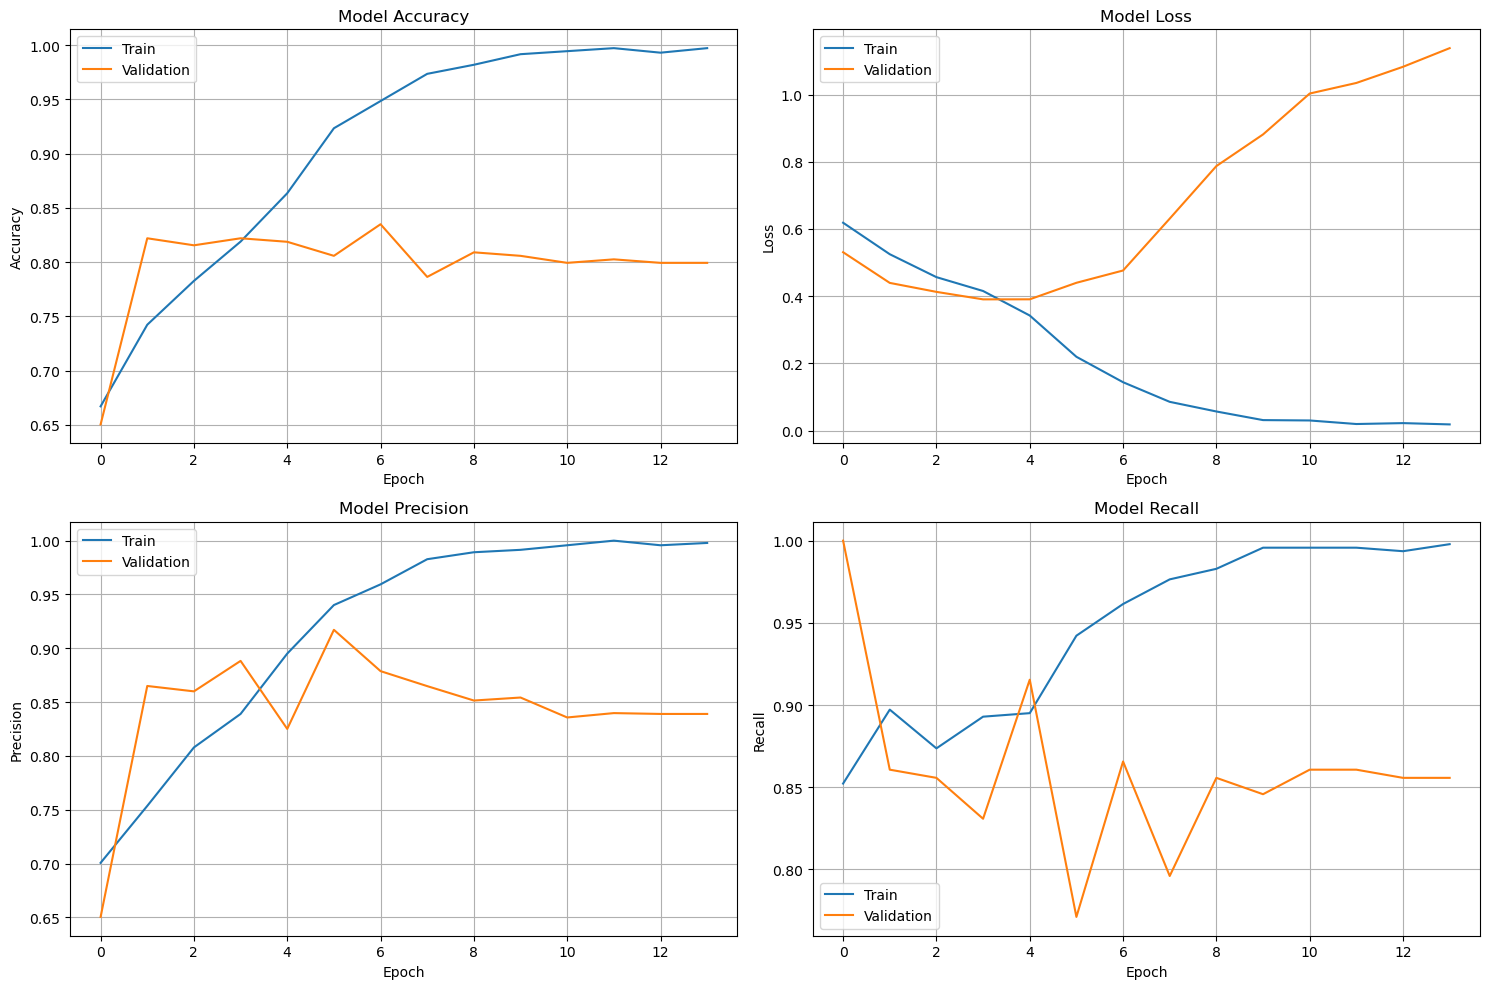

Training history plot saved as 'training_history.png'
10/10 [==============================] - 0s 28ms/step


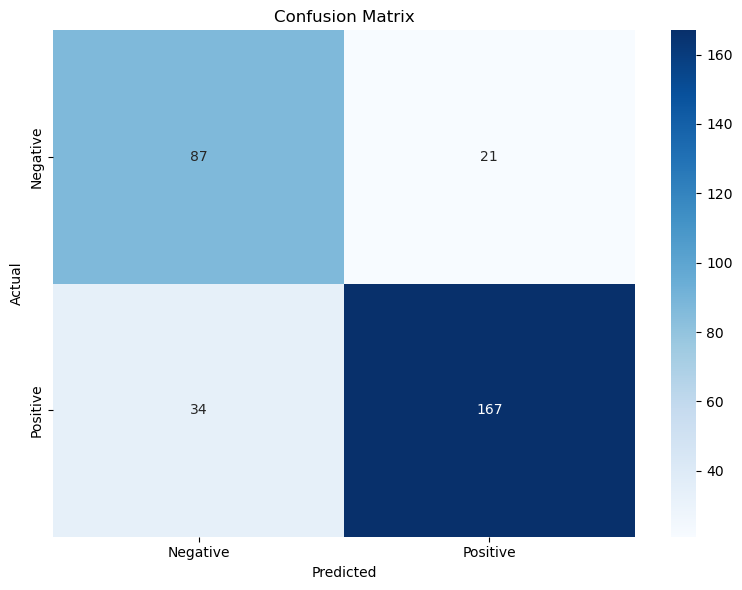

Confusion matrix saved as 'confusion_matrix.png'

Saving model...
Model saved as 'smart_trust_meter_model.h5'
Tokenizer saved as 'smart_trust_meter_model_tokenizer.pickle'
Scaler saved as 'smart_trust_meter_model_scaler.pickle'
Metrics saved as 'smart_trust_meter_model_metrics.pickle'

TRAINING PIPELINE COMPLETE!

Final Test Accuracy: 82.20%
F1 Score: 0.8586


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
import pandas as pd
import numpy as np
import pickle
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Input, concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

class TrustMeterTrainer:
    def __init__(self, max_words=5000, max_len=100):
        self.max_words = max_words
        self.max_len = max_len
        self.tokenizer = None
        self.scaler = StandardScaler()
        self.model = None
        self.history = None
        
    def preprocess_text(self, text):
        """Clean and preprocess text"""
        if pd.isna(text):
            return ""
        
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        text = ' '.join(text.split())
        
        return text
    
    def extract_sentiment_features(self, text):
        """Extract sentiment features using TextBlob"""
        try:
            blob = TextBlob(str(text))
            return {
                'polarity': blob.sentiment.polarity,
                'subjectivity': blob.sentiment.subjectivity,
                'text_length': len(text),
                'word_count': len(text.split()),
                'exclamation_count': text.count('!'),
                'question_count': text.count('?'),
            }
        except:
            return {
                'polarity': 0.0,
                'subjectivity': 0.0,
                'text_length': 0,
                'word_count': 0,
                'exclamation_count': 0,
                'question_count': 0,
            }
    
    def load_and_prepare_data(self, train_file='training_data.csv', test_file='testing_data.csv'):
        """Load training and testing data"""
        print("Loading data...")
        
        train_df = pd.read_csv(train_file)
        test_df = pd.read_csv(test_file)
        
        print(f"Training samples: {len(train_df)}")
        print(f"Testing samples: {len(test_df)}")
        
        # Preprocess text
        print("\nPreprocessing text...")
        train_df['clean_text'] = train_df['review_text'].apply(self.preprocess_text)
        test_df['clean_text'] = test_df['review_text'].apply(self.preprocess_text)
        
        # Extract sentiment features
        print("Extracting sentiment features...")
        train_features = train_df['clean_text'].apply(self.extract_sentiment_features)
        test_features = test_df['clean_text'].apply(self.extract_sentiment_features)
        
        train_features_df = pd.DataFrame(train_features.tolist())
        test_features_df = pd.DataFrame(test_features.tolist())
        
        # Tokenize text
        print("Tokenizing text...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(train_df['clean_text'])
        
        X_train_seq = self.tokenizer.texts_to_sequences(train_df['clean_text'])
        X_test_seq = self.tokenizer.texts_to_sequences(test_df['clean_text'])
        
        X_train_text = pad_sequences(X_train_seq, maxlen=self.max_len)
        X_test_text = pad_sequences(X_test_seq, maxlen=self.max_len)
        
        # Scale sentiment features
        X_train_features = self.scaler.fit_transform(train_features_df)
        X_test_features = self.scaler.transform(test_features_df)
        
        # Get labels
        y_train = train_df['label'].values
        y_test = test_df['label'].values
        
        print(f"\nData preparation complete!")
        print(f"Text sequences shape: {X_train_text.shape}")
        print(f"Features shape: {X_train_features.shape}")
        print(f"Labels distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")
        
        return (X_train_text, X_train_features, y_train), (X_test_text, X_test_features, y_test)
    
    def build_model(self, feature_dim):
        """Build LSTM model with dual inputs"""
        print("\nBuilding LSTM model...")
        
        # Text input branch
        text_input = Input(shape=(self.max_len,), name='text_input')
        embedding = Embedding(self.max_words, 128, input_length=self.max_len)(text_input)
        lstm1 = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(embedding)
        lstm2 = LSTM(32, dropout=0.2, recurrent_dropout=0.2)(lstm1)
        
        # Feature input branch
        feature_input = Input(shape=(feature_dim,), name='feature_input')
        dense_features = Dense(16, activation='relu')(feature_input)
        dropout_features = Dropout(0.3)(dense_features)
        
        # Concatenate both branches
        combined = concatenate([lstm2, dropout_features])
        
        # Dense layers
        dense1 = Dense(64, activation='relu')(combined)
        dropout1 = Dropout(0.3)(dense1)
        dense2 = Dense(32, activation='relu')(dropout1)
        dropout2 = Dropout(0.3)(dense2)
        
        # Output layer
        output = Dense(1, activation='sigmoid')(dropout2)
        
        # Create model
        self.model = Model(inputs=[text_input, feature_input], outputs=output)
        
        # Compile
        self.model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )
        
        print("\nModel architecture:")
        self.model.summary()
        
        return self.model
    
    def train_model(self, train_data, test_data, epochs=50, batch_size=32):
        """Train the LSTM model"""
        print("\n" + "="*60)
        print("STARTING MODEL TRAINING")
        print("="*60)
        
        X_train_text, X_train_features, y_train = train_data
        X_test_text, X_test_features, y_test = test_data
        
        # Build model
        feature_dim = X_train_features.shape[1]
        self.build_model(feature_dim)
        
        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=0.00001,
                verbose=1
            ),
            ModelCheckpoint(
                'best_trust_meter_model.h5',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            )
        ]
        
        # Train
        print("\nTraining model...")
        self.history = self.model.fit(
            [X_train_text, X_train_features],
            y_train,
            validation_data=([X_test_text, X_test_features], y_test),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        print("\n" + "="*60)
        print("TRAINING COMPLETE")
        print("="*60)
        
        return self.history
    
    def evaluate_model(self, test_data):
        """Evaluate model with comprehensive metrics"""
        print("\n" + "="*60)
        print("MODEL EVALUATION")
        print("="*60)
        
        X_test_text, X_test_features, y_test = test_data
        
        # Predictions
        y_pred_prob = self.model.predict([X_test_text, X_test_features])
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Regression metrics (treating as continuous)
        mse = mean_squared_error(y_test, y_pred_prob)
        mae = mean_absolute_error(y_test, y_pred_prob)
        rmse = np.sqrt(mse)
        
        # Print results
        print("\nClassification Metrics:")
        print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1 Score:  {f1:.4f}")
        
        print("\nRegression Metrics:")
        print(f"MSE:  {mse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        print("\nConfusion Matrix:")
        print(f"True Negative:  {cm[0][0]}")
        print(f"False Positive: {cm[0][1]}")
        print(f"False Negative: {cm[1][0]}")
        print(f"True Positive:  {cm[1][1]}")
        
        # Store metrics
        self.metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'mse': mse,
            'mae': mae,
            'rmse': rmse
        }
        
        return self.metrics
    
    def plot_training_history(self):
        """Plot training history"""
        if not self.history:
            print("No training history available!")
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Accuracy
        ax1.plot(self.history.history['accuracy'], label='Train')
        ax1.plot(self.history.history['val_accuracy'], label='Validation')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True)
        
        # Loss
        ax2.plot(self.history.history['loss'], label='Train')
        ax2.plot(self.history.history['val_loss'], label='Validation')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True)
        
        # Precision
        ax3.plot(self.history.history['precision'], label='Train')
        ax3.plot(self.history.history['val_precision'], label='Validation')
        ax3.set_title('Model Precision')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Precision')
        ax3.legend()
        ax3.grid(True)
        
        # Recall
        ax4.plot(self.history.history['recall'], label='Train')
        ax4.plot(self.history.history['val_recall'], label='Validation')
        ax4.set_title('Model Recall')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Recall')
        ax4.legend()
        ax4.grid(True)
        
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Training history plot saved as 'training_history.png'")
    
    def plot_confusion_matrix(self, test_data):
        """Plot confusion matrix"""
        X_test_text, X_test_features, y_test = test_data
        
        y_pred_prob = self.model.predict([X_test_text, X_test_features])
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Confusion matrix saved as 'confusion_matrix.png'")
    
    def save_model(self, model_path='smart_trust_meter_model'):
        """Save model and preprocessors"""
        print("\nSaving model...")
        
        # Save Keras model
        self.model.save(f'{model_path}.h5')
        
        # Save tokenizer
        with open(f'{model_path}_tokenizer.pickle', 'wb') as f:
            pickle.dump(self.tokenizer, f)
        
        # Save scaler
        with open(f'{model_path}_scaler.pickle', 'wb') as f:
            pickle.dump(self.scaler, f)
        
        # Save metrics
        with open(f'{model_path}_metrics.pickle', 'wb') as f:
            pickle.dump(self.metrics, f)
        
        print(f"Model saved as '{model_path}.h5'")
        print(f"Tokenizer saved as '{model_path}_tokenizer.pickle'")
        print(f"Scaler saved as '{model_path}_scaler.pickle'")
        print(f"Metrics saved as '{model_path}_metrics.pickle'")
    
    def load_model(self, model_path='smart_trust_meter_model'):
        """Load saved model"""
        print("Loading model...")
        
        self.model = tf.keras.models.load_model(f'{model_path}.h5')
        
        with open(f'{model_path}_tokenizer.pickle', 'rb') as f:
            self.tokenizer = pickle.load(f)
        
        with open(f'{model_path}_scaler.pickle', 'rb') as f:
            self.scaler = pickle.load(f)
        
        print("Model loaded successfully!")

# Complete training workflow
def train_trust_meter_model():
    """Complete training pipeline"""
    print("SMART TRUST METER - MODEL TRAINING PIPELINE")
    print("="*60)
    
    # Initialize trainer
    trainer = TrustMeterTrainer(max_words=5000, max_len=100)
    
    # Load and prepare data
    train_data, test_data = trainer.load_and_prepare_data(
        train_file='training_data.csv',
        test_file='testing_data.csv'
    )
    
    # Train model
    history = trainer.train_model(
        train_data, 
        test_data, 
        epochs=50,
        batch_size=32
    )
    
    # Evaluate model
    metrics = trainer.evaluate_model(test_data)
    
    # Plot results
    trainer.plot_training_history()
    trainer.plot_confusion_matrix(test_data)
    
    # Save model
    trainer.save_model('smart_trust_meter_model')
    
    print("\n" + "="*60)
    print("TRAINING PIPELINE COMPLETE!")
    print("="*60)
    print(f"\nFinal Test Accuracy: {metrics['accuracy']*100:.2f}%")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    
    return trainer, metrics

if __name__ == "__main__":
    trainer, metrics = train_trust_meter_model()

# Aspects

ASPECT-BASED SENTIMENT ANALYSIS

This tool extracts and analyzes specific aspects like:
- Pricing, Service Quality, Parts Availability
- Time Efficiency, Repair Quality, Cleanliness
- Expertise, Communication, Warranty, Location

Loading Suzuki Adil Zafar Motors.csv...
Analyzing 298 reviews...

ASPECT-BASED SENTIMENT ANALYSIS: Suzuki Adil Zafar Motors

Aspect               Mentions   Sentiment       Positive   Negative  
----------------------------------------------------------------------
Service Quality      133        +0.398 (Very Positive)  75.9%       9.0%
Repair Quality       52         +0.404 (Very Positive)  71.2%       5.8%
Location Facility    33         +0.395 (Very Positive)  69.7%       9.1%
Pricing              30         +0.114 (Positive)  50.0%      23.3%
Cleanliness          23         +0.446 (Very Positive)  78.3%       4.3%
Parts Availability   21         +0.301 (Very Positive)  76.2%       4.8%
Expertise            18         +0.272 (Positive)  61.1%       5.6%
Tim

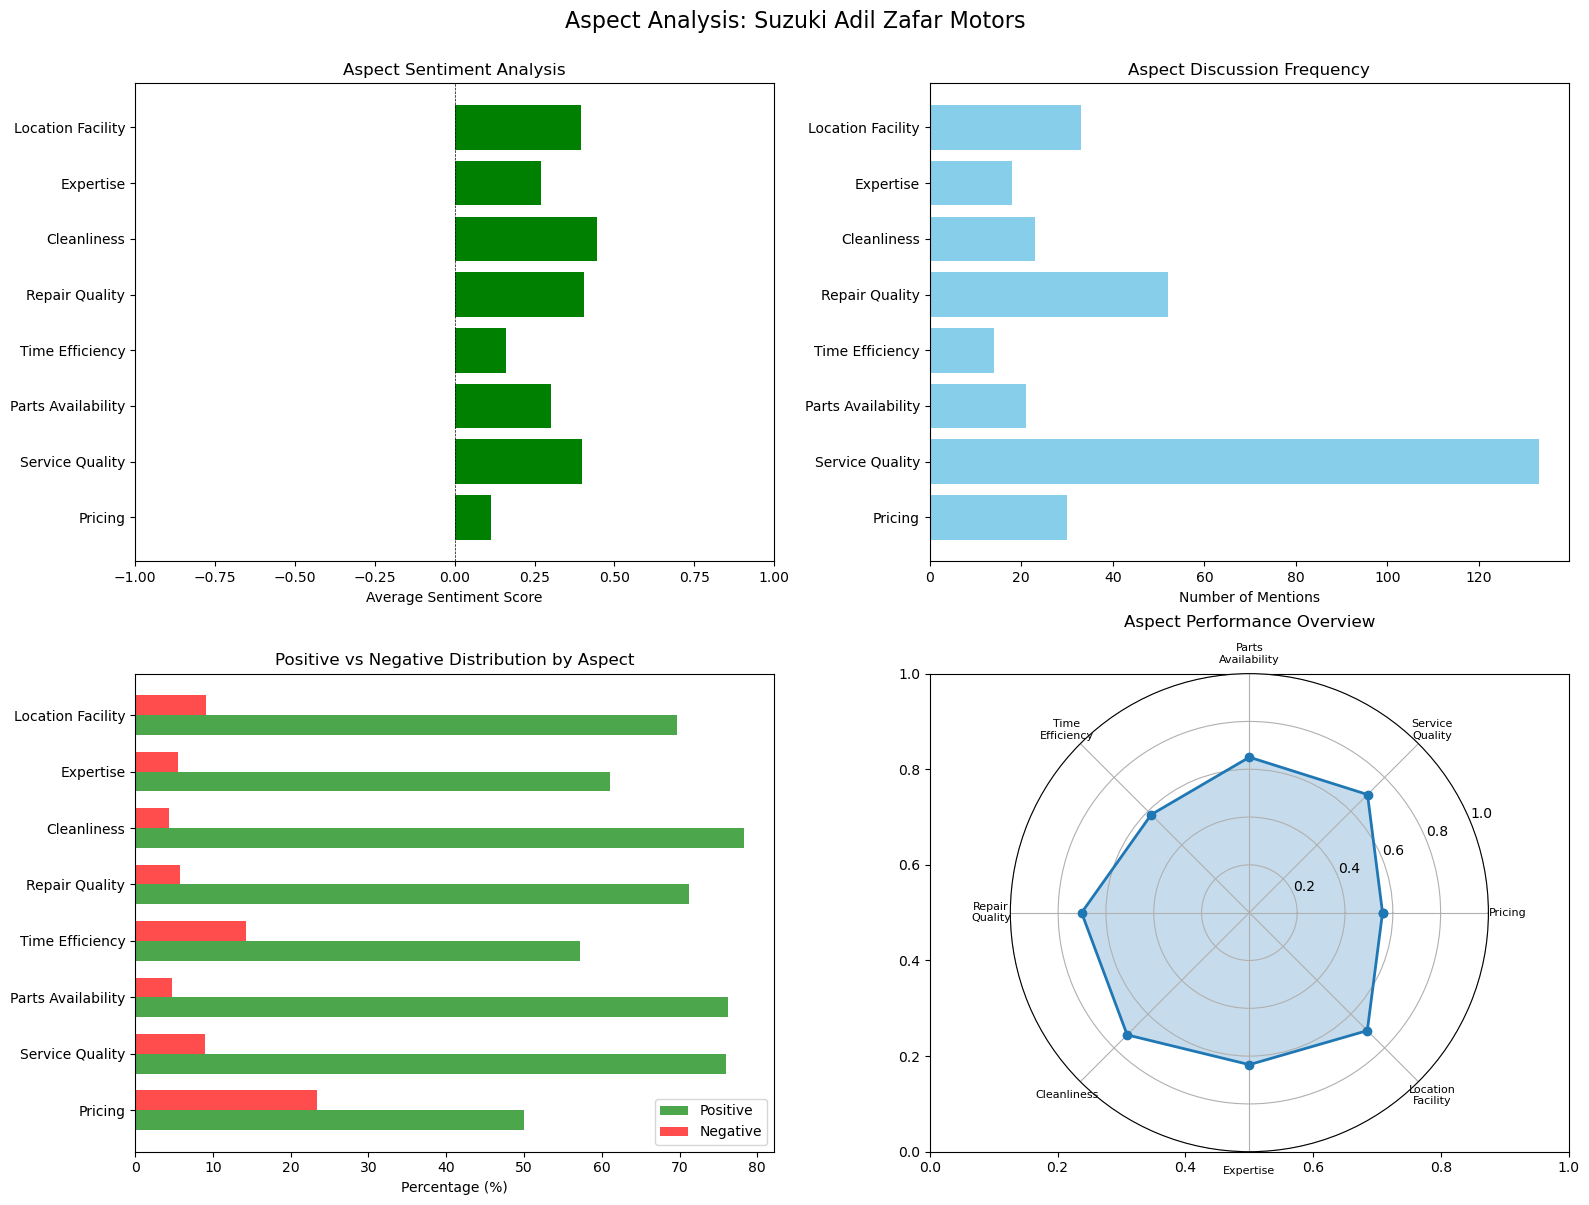


Visualization saved as 'Suzuki Adil Zafar Motors_aspect_analysis.png'

Aspect summary exported to 'Suzuki Adil Zafar Motors_aspect_summary.csv'


In [2]:
import pandas as pd
import numpy as np
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

class AspectBasedAnalyzer:
    def __init__(self):
        # Define aspect keywords for car dealerships
        self.aspect_keywords = {
            'pricing': [
                'price', 'cost', 'expensive', 'cheap', 'affordable', 'overpriced', 
                'reasonable', 'budget', 'money', 'payment', 'rate', 'charge',
                'worth', 'value', 'costly', 'economical', 'pricey'
            ],
            'service_quality': [
                'service', 'staff', 'helpful', 'professional', 'rude', 'friendly',
                'polite', 'courteous', 'attitude', 'behavior', 'customer service',
                'treatment', 'reception', 'welcoming', 'respectful'
            ],
            'parts_availability': [
                'parts', 'spare parts', 'availability', 'stock', 'genuine',
                'original', 'replacement', 'component', 'accessories', 'available',
                'in stock', 'out of stock', 'imported', 'local parts'
            ],
            'time_efficiency': [
                'time', 'wait', 'quick', 'slow', 'delay', 'fast', 'hours',
                'minutes', 'prompt', 'timely', 'punctual', 'late', 'on time',
                'waiting', 'duration', 'speed', 'efficient', 'immediately'
            ],
            'repair_quality': [
                'repair', 'fix', 'work', 'quality', 'workmanship', 'job',
                'maintenance', 'condition', 'problem', 'issue', 'damage',
                'fixed', 'repaired', 'maintained', 'serviced', 'working'
            ],
            'cleanliness': [
                'clean', 'dirty', 'neat', 'organized', 'messy', 'hygiene',
                'tidy', 'maintained', 'facility', 'premises', 'environment',
                'washroom', 'waiting area', 'workshop'
            ],
            'expertise': [
                'expert', 'skilled', 'knowledge', 'experienced', 'amateur',
                'professional', 'competent', 'qualified', 'trained', 'mechanic',
                'technician', 'specialist', 'capable', 'proficient'
            ],
            'communication': [
                'explain', 'information', 'update', 'inform', 'communicate',
                'feedback', 'response', 'answer', 'clarify', 'transparent',
                'honest', 'clear', 'detailed', 'status', 'progress'
            ],
            'warranty': [
                'warranty', 'guarantee', 'assurance', 'coverage', 'claim',
                'policy', 'terms', 'conditions', 'protection', 'backed'
            ],
            'location_facility': [
                'location', 'parking', 'accessible', 'facility', 'building',
                'premises', 'convenient', 'far', 'near', 'distance', 'place'
            ]
        }
        
        # Initialize results storage
        self.aspect_sentiments = defaultdict(list)
        self.aspect_mentions = defaultdict(int)
    
    def find_aspect_sentences(self, text, aspect_name):
        """Find sentences in text that mention a specific aspect"""
        if pd.isna(text):
            return []
        
        text = str(text).lower()
        sentences = re.split(r'[.!?]+', text)
        
        aspect_sentences = []
        keywords = self.aspect_keywords[aspect_name]
        
        for sentence in sentences:
            sentence = sentence.strip()
            if len(sentence) < 5:
                continue
            
            # Check if any keyword is in the sentence
            for keyword in keywords:
                if keyword in sentence:
                    aspect_sentences.append(sentence)
                    break
        
        return aspect_sentences
    
    def get_aspect_sentiment(self, sentences):
        """Calculate sentiment for aspect-specific sentences"""
        if not sentences:
            return None
        
        sentiments = []
        for sentence in sentences:
            try:
                blob = TextBlob(sentence)
                sentiments.append(blob.sentiment.polarity)
            except:
                continue
        
        if not sentiments:
            return None
        
        return np.mean(sentiments)
    
    def analyze_review(self, review_text):
        """Analyze a single review for all aspects"""
        aspects_found = {}
        
        for aspect_name in self.aspect_keywords.keys():
            # Find sentences mentioning this aspect
            aspect_sentences = self.find_aspect_sentences(review_text, aspect_name)
            
            if aspect_sentences:
                # Calculate sentiment for this aspect
                sentiment = self.get_aspect_sentiment(aspect_sentences)
                
                if sentiment is not None:
                    aspects_found[aspect_name] = {
                        'sentiment': sentiment,
                        'sentences': aspect_sentences,
                        'num_mentions': len(aspect_sentences)
                    }
                    
                    # Store for aggregate analysis
                    self.aspect_sentiments[aspect_name].append(sentiment)
                    self.aspect_mentions[aspect_name] += 1
        
        return aspects_found
    
    def analyze_dealership(self, df, text_column='wiI7pd'):
        """Analyze all reviews for a dealership"""
        print(f"Analyzing {len(df)} reviews...")
        
        # Reset storage
        self.aspect_sentiments = defaultdict(list)
        self.aspect_mentions = defaultdict(int)
        
        # Analyze each review
        all_aspects = []
        for idx, row in df.iterrows():
            review_text = row[text_column]
            aspects = self.analyze_review(review_text)
            all_aspects.append(aspects)
        
        # Calculate aggregate statistics
        aspect_summary = {}
        for aspect_name in self.aspect_keywords.keys():
            if self.aspect_sentiments[aspect_name]:
                sentiments = self.aspect_sentiments[aspect_name]
                
                # Calculate statistics
                avg_sentiment = np.mean(sentiments)
                positive_count = sum(1 for s in sentiments if s > 0.1)
                negative_count = sum(1 for s in sentiments if s < -0.1)
                neutral_count = len(sentiments) - positive_count - negative_count
                
                aspect_summary[aspect_name] = {
                    'mentions': self.aspect_mentions[aspect_name],
                    'avg_sentiment': avg_sentiment,
                    'positive_reviews': positive_count,
                    'negative_reviews': negative_count,
                    'neutral_reviews': neutral_count,
                    'sentiment_category': self.categorize_sentiment(avg_sentiment),
                    'percentage_positive': (positive_count / len(sentiments)) * 100,
                    'percentage_negative': (negative_count / len(sentiments)) * 100
                }
        
        return aspect_summary, all_aspects
    
    def categorize_sentiment(self, sentiment_score):
        """Convert sentiment score to category"""
        if sentiment_score > 0.3:
            return "Very Positive"
        elif sentiment_score > 0.1:
            return "Positive"
        elif sentiment_score > -0.1:
            return "Neutral"
        elif sentiment_score > -0.3:
            return "Negative"
        else:
            return "Very Negative"
    
    def print_aspect_report(self, aspect_summary, dealership_name):
        """Print formatted aspect analysis report"""
        print("\n" + "="*70)
        print(f"ASPECT-BASED SENTIMENT ANALYSIS: {dealership_name}")
        print("="*70)
        
        # Sort by number of mentions
        sorted_aspects = sorted(
            aspect_summary.items(), 
            key=lambda x: x[1]['mentions'], 
            reverse=True
        )
        
        print(f"\n{'Aspect':<20} {'Mentions':<10} {'Sentiment':<15} {'Positive':<10} {'Negative':<10}")
        print("-"*70)
        
        for aspect_name, stats in sorted_aspects:
            aspect_display = aspect_name.replace('_', ' ').title()
            sentiment_display = f"{stats['avg_sentiment']:+.3f} ({stats['sentiment_category']})"
            
            print(f"{aspect_display:<20} {stats['mentions']:<10} {sentiment_display:<15} "
                  f"{stats['percentage_positive']:>5.1f}% {stats['percentage_negative']:>9.1f}%")
        
        # Key insights
        print("\n" + "="*70)
        print("KEY INSIGHTS")
        print("="*70)
        
        # Most mentioned aspects
        top_3_mentioned = sorted_aspects[:3]
        print("\nMost Discussed Aspects:")
        for i, (aspect, stats) in enumerate(top_3_mentioned, 1):
            print(f"{i}. {aspect.replace('_', ' ').title()}: {stats['mentions']} mentions")
        
        # Best rated aspects
        best_aspects = sorted(
            [(k, v) for k, v in aspect_summary.items() if v['mentions'] >= 5],
            key=lambda x: x[1]['avg_sentiment'],
            reverse=True
        )[:3]
        
        if best_aspects:
            print("\nBest Performing Aspects:")
            for i, (aspect, stats) in enumerate(best_aspects, 1):
                print(f"{i}. {aspect.replace('_', ' ').title()}: "
                      f"{stats['avg_sentiment']:+.3f} ({stats['percentage_positive']:.1f}% positive)")
        
        # Worst rated aspects
        worst_aspects = sorted(
            [(k, v) for k, v in aspect_summary.items() if v['mentions'] >= 5],
            key=lambda x: x[1]['avg_sentiment']
        )[:3]
        
        if worst_aspects:
            print("\nAreas for Improvement:")
            for i, (aspect, stats) in enumerate(worst_aspects, 1):
                print(f"{i}. {aspect.replace('_', ' ').title()}: "
                      f"{stats['avg_sentiment']:+.3f} ({stats['percentage_negative']:.1f}% negative)")
    
    def visualize_aspects(self, aspect_summary, dealership_name):
        """Create visualizations for aspect analysis"""
        # Filter aspects with at least 5 mentions
        significant_aspects = {k: v for k, v in aspect_summary.items() if v['mentions'] >= 5}
        
        if not significant_aspects:
            print("Not enough data for visualization")
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Aspect Sentiment Scores
        aspects = list(significant_aspects.keys())
        sentiments = [significant_aspects[a]['avg_sentiment'] for a in aspects]
        
        colors = ['green' if s > 0.1 else 'red' if s < -0.1 else 'gray' for s in sentiments]
        bars = ax1.barh([a.replace('_', ' ').title() for a in aspects], sentiments, color=colors)
        ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        ax1.set_xlabel('Average Sentiment Score')
        ax1.set_title('Aspect Sentiment Analysis')
        ax1.set_xlim(-1, 1)
        
        # 2. Mention Frequency
        mentions = [significant_aspects[a]['mentions'] for a in aspects]
        ax2.barh([a.replace('_', ' ').title() for a in aspects], mentions, color='skyblue')
        ax2.set_xlabel('Number of Mentions')
        ax2.set_title('Aspect Discussion Frequency')
        
        # 3. Positive vs Negative Distribution
        aspect_names = [a.replace('_', ' ').title() for a in aspects]
        positive_pcts = [significant_aspects[a]['percentage_positive'] for a in aspects]
        negative_pcts = [significant_aspects[a]['percentage_negative'] for a in aspects]
        
        x = np.arange(len(aspects))
        width = 0.35
        
        ax3.barh(x - width/2, positive_pcts, width, label='Positive', color='green', alpha=0.7)
        ax3.barh(x + width/2, negative_pcts, width, label='Negative', color='red', alpha=0.7)
        ax3.set_yticks(x)
        ax3.set_yticklabels(aspect_names)
        ax3.set_xlabel('Percentage (%)')
        ax3.set_title('Positive vs Negative Distribution by Aspect')
        ax3.legend()
        
        # 4. Radar Chart
        from math import pi
        
        categories = [a.replace('_', '\n').title() for a in aspects]
        values = [(s + 1) / 2 for s in sentiments]  # Normalize to 0-1
        values += values[:1]  # Complete the circle
        
        angles = [n / float(len(aspects)) * 2 * pi for n in range(len(aspects))]
        angles += angles[:1]
        
        ax4 = plt.subplot(224, projection='polar')
        ax4.plot(angles, values, 'o-', linewidth=2)
        ax4.fill(angles, values, alpha=0.25)
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(categories, size=8)
        ax4.set_ylim(0, 1)
        ax4.set_title('Aspect Performance Overview', y=1.08)
        ax4.grid(True)
        
        plt.suptitle(f'Aspect Analysis: {dealership_name}', fontsize=16, y=1.00)
        plt.tight_layout()
        plt.savefig(f'{dealership_name}_aspect_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nVisualization saved as '{dealership_name}_aspect_analysis.png'")
    
    def export_to_dataframe(self, aspect_summary):
        """Export aspect summary to DataFrame"""
        data = []
        for aspect, stats in aspect_summary.items():
            data.append({
                'Aspect': aspect.replace('_', ' ').title(),
                'Mentions': stats['mentions'],
                'Avg Sentiment': stats['avg_sentiment'],
                'Category': stats['sentiment_category'],
                'Positive %': stats['percentage_positive'],
                'Negative %': stats['percentage_negative'],
                'Positive Count': stats['positive_reviews'],
                'Negative Count': stats['negative_reviews']
            })
        
        return pd.DataFrame(data).sort_values('Mentions', ascending=False)

# Easy-to-use functions
def analyze_single_dealership(csv_file, dealership_name=None):
    """Analyze a single dealership file"""
    if dealership_name is None:
        dealership_name = csv_file.replace('.csv', '').replace('_', ' ')
    
    print(f"Loading {csv_file}...")
    df = pd.read_csv(csv_file, encoding='unicode_escape')
    
    analyzer = AspectBasedAnalyzer()
    aspect_summary, all_aspects = analyzer.analyze_dealership(df, text_column='wiI7pd')
    
    analyzer.print_aspect_report(aspect_summary, dealership_name)
    analyzer.visualize_aspects(aspect_summary, dealership_name)
    
    # Export to CSV
    summary_df = analyzer.export_to_dataframe(aspect_summary)
    output_file = f'{dealership_name}_aspect_summary.csv'
    summary_df.to_csv(output_file, index=False)
    print(f"\nAspect summary exported to '{output_file}'")
    
    return analyzer, aspect_summary, summary_df

def analyze_all_dealerships(data_directory="./"):
    """Analyze all dealership files"""
    from glob import glob
    import os
    
    csv_files = glob(os.path.join(data_directory, "*.csv"))
    csv_files = [f for f in csv_files if 'aspect' not in f and 'backup' not in f]
    
    print(f"Found {len(csv_files)} dealership files")
    
    all_summaries = {}
    
    for csv_file in csv_files:
        dealership_name = os.path.basename(csv_file).replace('.csv', '')
        print(f"\n{'='*70}")
        print(f"Processing: {dealership_name}")
        print("="*70)
        
        try:
            analyzer, aspect_summary, summary_df = analyze_single_dealership(csv_file, dealership_name)
            all_summaries[dealership_name] = aspect_summary
        except Exception as e:
            print(f"Error processing {dealership_name}: {e}")
    
    return all_summaries

def compare_dealerships_by_aspect(all_summaries, aspect_name='pricing'):
    """Compare all dealerships on a specific aspect"""
    print(f"\n{'='*70}")
    print(f"DEALERSHIP COMPARISON: {aspect_name.replace('_', ' ').title()}")
    print("="*70)
    
    comparison_data = []
    
    for dealership, aspects in all_summaries.items():
        if aspect_name in aspects:
            stats = aspects[aspect_name]
            comparison_data.append({
                'Dealership': dealership,
                'Sentiment': stats['avg_sentiment'],
                'Category': stats['sentiment_category'],
                'Mentions': stats['mentions'],
                'Positive %': stats['percentage_positive']
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data).sort_values('Sentiment', ascending=False)
        print(comparison_df.to_string(index=False))
        return comparison_df
    else:
        print(f"No data found for aspect: {aspect_name}")
        return None

if __name__ == "__main__":
    # Example usage
    print("ASPECT-BASED SENTIMENT ANALYSIS")
    print("="*70)
    print("\nThis tool extracts and analyzes specific aspects like:")
    print("- Pricing, Service Quality, Parts Availability")
    print("- Time Efficiency, Repair Quality, Cleanliness")
    print("- Expertise, Communication, Warranty, Location\n")
    
    # Analyze single dealership
    analyzer, summary, df = analyze_single_dealership("Suzuki Adil Zafar Motors.csv")

SMART TRUST METER - COMPLETE PIPELINE

This pipeline:
1. Predicts sentiment for ALL reviews (labeled + unlabeled)
2. Calculates overall trust score
3. Extracts aspect-level insights using your trained LSTM
4. Creates visualizations

Ready to analyze!

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/HONDA Fort_ready_for_labeling.csv
Total reviews: 349
Valid reviews: 343

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.650
  Positive reviews: 208 (60.6%)
  Negative reviews: 135 (39.4%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/HONDA Fort_ready_for_labeling
Total Reviews Analyzed: 343

OVERALL TRUST SCORE: 0.650/1.00 (Good)

Sentiment Distribution:
  Positive: 208 reviews (60.6%)
  Negative: 135 reviews (39.4%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.670    Good            187        62.6%     
Repair Quality       0.673    Good            58         67.2%     
Expertise            0.559    Average         47         40.4%     
Pricing              0.386    Poor            36         30.6%     
Time Efficiency      0.490    Below Average   36         36.1%     
Parts Availability   0.718    Excellent       15         80.0%     
Co

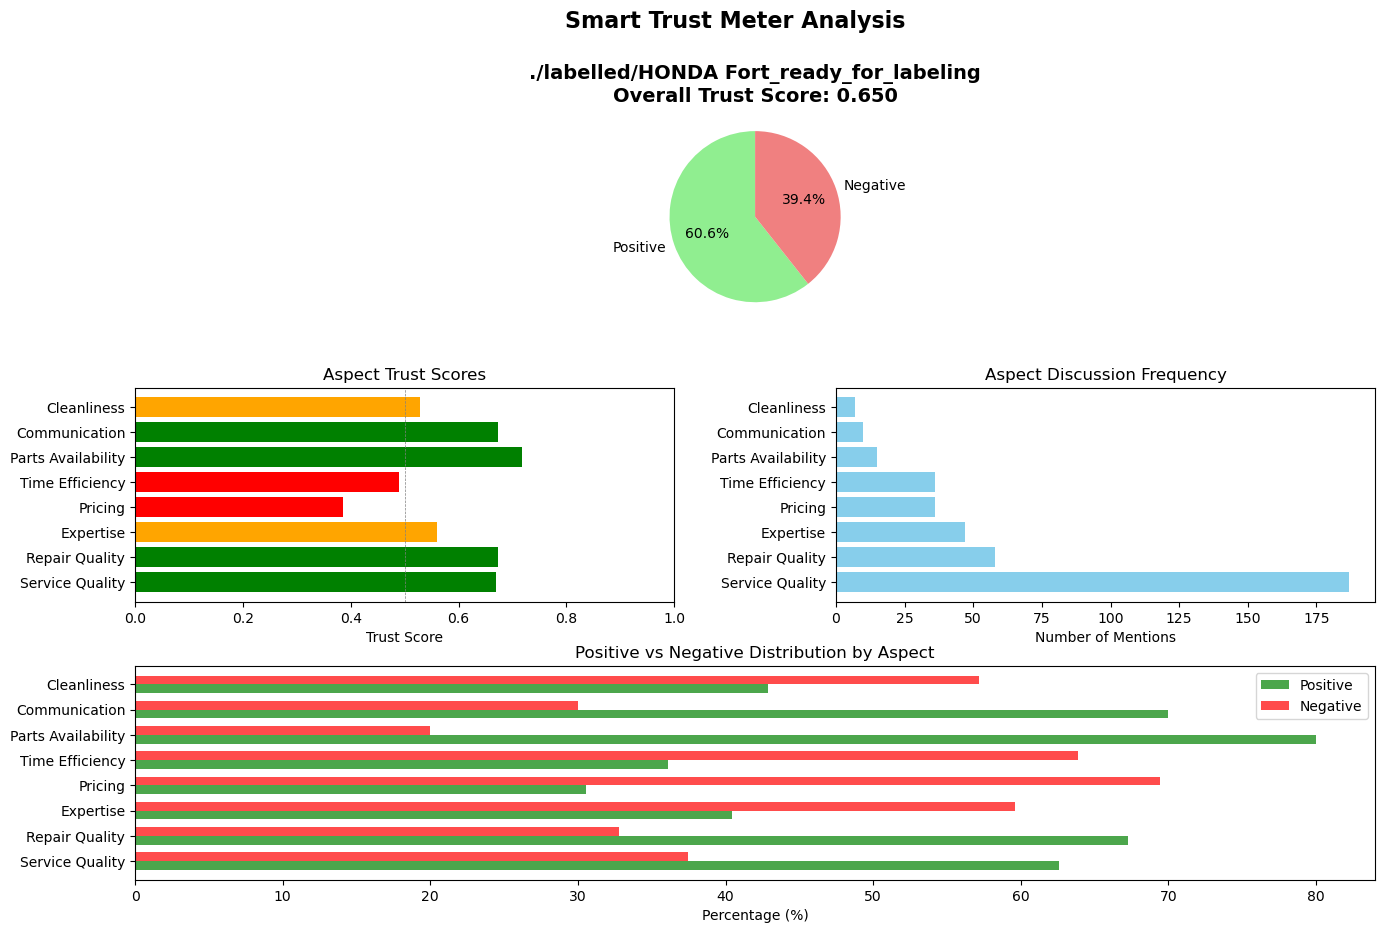

In [3]:
import pandas as pd
import numpy as np
import pickle
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from textblob import TextBlob
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

class CompleteTrustMeterPipeline:
    def __init__(self, model_path='smart_trust_meter_model'):
        """Load trained LSTM model and preprocessors"""
        print("Loading trained model...")
        self.model = tf.keras.models.load_model(f'{model_path}.h5')
        
        with open(f'{model_path}_tokenizer.pickle', 'rb') as f:
            self.tokenizer = pickle.load(f)
        
        with open(f'{model_path}_scaler.pickle', 'rb') as f:
            self.scaler = pickle.load(f)
        
        self.max_len = 100
        
        # Aspect keywords dictionary
        self.aspects = {
            'pricing': ['price', 'cost', 'expensive', 'cheap', 'affordable', 'overpriced', 'reasonable', 'money', 'payment', 'charge'],
            'service_quality': ['service', 'staff', 'helpful', 'professional', 'rude', 'friendly', 'polite', 'courteous', 'attitude', 'behavior'],
            'parts_availability': ['parts', 'spare', 'availability', 'stock', 'genuine', 'original', 'replacement', 'component'],
            'time_efficiency': ['time', 'wait', 'quick', 'slow', 'delay', 'fast', 'prompt', 'hours', 'minutes', 'timely', 'punctual'],
            'repair_quality': ['repair', 'fix', 'work', 'quality', 'workmanship', 'maintenance', 'condition', 'fixed', 'repaired'],
            'cleanliness': ['clean', 'dirty', 'neat', 'organized', 'hygiene', 'tidy', 'maintained', 'facility', 'environment'],
            'expertise': ['expert', 'skilled', 'knowledge', 'experienced', 'professional', 'qualified', 'trained', 'competent', 'mechanic'],
            'communication': ['explain', 'information', 'update', 'communicate', 'transparent', 'honest', 'clear', 'inform', 'feedback']
        }
        
        print("Model loaded successfully!")
    
    def preprocess_text(self, text):
        """Clean text"""
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        return ' '.join(text.split())
    
    def extract_features(self, text):
        """Extract TextBlob features"""
        try:
            blob = TextBlob(str(text))
            return np.array([
                blob.sentiment.polarity,
                blob.sentiment.subjectivity,
                len(text),
                len(text.split()),
                text.count('!'),
                text.count('?')
            ])
        except:
            return np.array([0, 0, 0, 0, 0, 0])
    
    def predict_sentiment(self, texts):
        """Predict sentiment using LSTM for a list of texts"""
        if len(texts) == 0:
            return np.array([])
        
        # Preprocess
        clean_texts = [self.preprocess_text(t) for t in texts]
        
        # Tokenize and pad
        sequences = self.tokenizer.texts_to_sequences(clean_texts)
        X_text = pad_sequences(sequences, maxlen=self.max_len)
        
        # Extract features
        X_features = np.array([self.extract_features(t) for t in clean_texts])
        X_features = self.scaler.transform(X_features)
        
        # Predict
        predictions = self.model.predict([X_text, X_features], verbose=0)
        return predictions.flatten()
    
    def find_aspect_sentences(self, text, aspect_keywords):
        """Find sentences mentioning an aspect"""
        if pd.isna(text):
            return []
        
        text = str(text).lower()
        sentences = re.split(r'[.!?]+', text)
        
        aspect_sents = []
        for sent in sentences:
            sent = sent.strip()
            if len(sent) > 5:
                if any(kw in sent for kw in aspect_keywords):
                    aspect_sents.append(sent)
        
        return aspect_sents
    
    def analyze_complete_dealership(self, csv_file, text_column='wiI7pd'):
        """
        COMPLETE ANALYSIS:
        1. Predict all unlabeled reviews
        2. Calculate overall trust score
        3. Extract aspect-level insights using LSTM
        """
        print(f"\n{'='*70}")
        print(f"ANALYZING: {csv_file}")
        print('='*70)
        
        # Load data
        df = pd.read_csv(csv_file, encoding='unicode_escape')
        print(f"Total reviews: {len(df)}")
        
        # Filter valid reviews
        df = df[df[text_column].notna()]
        df = df[df[text_column].astype(str).str.len() > 10]
        
        print(f"Valid reviews: {len(df)}")
        
        # ===== STEP 1: PREDICT ALL REVIEWS =====
        print("\n[1/3] Predicting sentiment for all reviews...")
        all_texts = df[text_column].tolist()
        all_predictions = self.predict_sentiment(all_texts)
        
        df['predicted_sentiment'] = all_predictions
        df['predicted_label'] = (all_predictions > 0.5).astype(int)
        
        # Overall statistics
        overall_trust_score = all_predictions.mean()
        positive_count = sum(df['predicted_label'] == 1)
        negative_count = sum(df['predicted_label'] == 0)
        
        print(f"Complete")
        print(f"  Overall Trust Score: {overall_trust_score:.3f}")
        print(f"  Positive reviews: {positive_count} ({positive_count/len(df)*100:.1f}%)")
        print(f"  Negative reviews: {negative_count} ({negative_count/len(df)*100:.1f}%)")
        
        # ===== STEP 2: ASPECT EXTRACTION =====
        print("\n[2/3] Extracting aspect-level insights...")
        
        aspect_results = {}
        
        for aspect_name, keywords in self.aspects.items():
            aspect_texts = []
            
            # Find all sentences mentioning this aspect
            for text in all_texts:
                sents = self.find_aspect_sentences(text, keywords)
                aspect_texts.extend(sents)
            
            if len(aspect_texts) > 0:
                # Predict sentiment for aspect-specific sentences using LSTM
                aspect_predictions = self.predict_sentiment(aspect_texts)
                
                avg_sentiment = aspect_predictions.mean()
                positive_pct = sum(aspect_predictions > 0.5) / len(aspect_predictions) * 100
                negative_pct = sum(aspect_predictions < 0.5) / len(aspect_predictions) * 100
                
                aspect_results[aspect_name] = {
                    'mentions': len(aspect_texts),
                    'avg_score': avg_sentiment,
                    'positive_pct': positive_pct,
                    'negative_pct': negative_pct,
                    'category': self.get_category(avg_sentiment)
                }
        
        print(f"Complete ({len(aspect_results)} aspects found)")
        
        # ===== STEP 3: GENERATE REPORT =====
        print("\n[3/3] Generating report...")
        self.print_report(csv_file, overall_trust_score, df, aspect_results)
        
        # Save results
        output_file = csv_file.replace('.csv', '_analyzed.csv')
        df.to_csv(output_file, index=False)
        print(f"\nResults saved to: {output_file}")
        
        return df, aspect_results, overall_trust_score
    
    def get_category(self, score):
        """Convert score to category"""
        if score > 0.7: return "Excellent"
        elif score > 0.6: return "Good"
        elif score > 0.5: return "Average"
        elif score > 0.4: return "Below Average"
        else: return "Poor"
    
    def print_report(self, dealership_name, trust_score, df, aspects):
        """Print comprehensive report"""
        print("\n" + "="*70)
        print("SMART TRUST METER REPORT")
        print("="*70)
        print(f"Dealership: {dealership_name.replace('.csv', '')}")
        print(f"Total Reviews Analyzed: {len(df)}")
        print(f"\nOVERALL TRUST SCORE: {trust_score:.3f}/1.00 ({self.get_category(trust_score)})")
        
        # Distribution
        pos = sum(df['predicted_label'] == 1)
        neg = sum(df['predicted_label'] == 0)
        print(f"\nSentiment Distribution:")
        print(f"  Positive: {pos} reviews ({pos/len(df)*100:.1f}%)")
        print(f"  Negative: {neg} reviews ({neg/len(df)*100:.1f}%)")
        
        # Aspect breakdown
        if aspects:
            print(f"\n{'-'*70}")
            print("ASPECT ANALYSIS")
            print(f"{'-'*70}")
            print(f"\n{'Aspect':<20} {'Score':<8} {'Rating':<15} {'Mentions':<10} {'Positive':<10}")
            print("-"*70)
            
            # Sort by mentions
            sorted_aspects = sorted(aspects.items(), key=lambda x: x[1]['mentions'], reverse=True)
            
            for asp_name, stats in sorted_aspects:
                display_name = asp_name.replace('_', ' ').title()
                score_str = f"{stats['avg_score']:.3f}"
                rating = stats['category']
                mentions = stats['mentions']
                pos_pct = f"{stats['positive_pct']:.1f}%"
                
                print(f"{display_name:<20} {score_str:<8} {rating:<15} {mentions:<10} {pos_pct:<10}")
            
            # Key insights
            print(f"\n{'-'*70}")
            print("KEY INSIGHTS")
            print(f"{'-'*70}")
            
            # Best aspects
            best = sorted([(k,v) for k,v in aspects.items() if v['mentions'] >= 5], 
                         key=lambda x: x[1]['avg_score'], reverse=True)[:3]
            if best:
                print("\nStrengths:")
                for asp, stats in best:
                    print(f"  - {asp.replace('_', ' ').title()}: {stats['avg_score']:.3f} ({stats['positive_pct']:.0f}% positive)")
            
            # Worst aspects
            worst = sorted([(k,v) for k,v in aspects.items() if v['mentions'] >= 5], 
                          key=lambda x: x[1]['avg_score'])[:3]
            if worst:
                print("\nAreas for Improvement:")
                for asp, stats in worst:
                    print(f"  - {asp.replace('_', ' ').title()}: {stats['avg_score']:.3f} ({stats['negative_pct']:.0f}% negative)")
    
    def visualize_results(self, dealership_name, trust_score, df, aspects):
        """Create visualizations"""
        if len(aspects) < 3:
            print("Not enough aspects for visualization")
            return
        
        fig = plt.figure(figsize=(16, 10))
        
        # Create grid
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, 0])
        ax3 = fig.add_subplot(gs[1, 1])
        ax4 = fig.add_subplot(gs[2, :])
        
        # 1. Overall sentiment distribution (pie)
        labels = ['Positive', 'Negative']
        sizes = [sum(df['predicted_label'] == 1), sum(df['predicted_label'] == 0)]
        colors = ['lightgreen', 'lightcoral']
        
        ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax1.set_title(f'{dealership_name.replace(".csv", "")}\nOverall Trust Score: {trust_score:.3f}', fontsize=14, fontweight='bold')
        
        # 2. Aspect scores
        sorted_aspects = sorted(aspects.items(), key=lambda x: x[1]['mentions'], reverse=True)
        aspect_names = [a[0].replace('_', ' ').title() for a in sorted_aspects]
        aspect_scores = [a[1]['avg_score'] for a in sorted_aspects]
        
        colors_aspects = ['green' if s > 0.6 else 'orange' if s > 0.5 else 'red' for s in aspect_scores]
        ax2.barh(aspect_names, aspect_scores, color=colors_aspects)
        ax2.set_xlabel('Trust Score')
        ax2.set_title('Aspect Trust Scores')
        ax2.set_xlim(0, 1)
        ax2.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.5)
        
        # 3. Mention frequency
        mentions = [a[1]['mentions'] for a in sorted_aspects]
        ax3.barh(aspect_names, mentions, color='skyblue')
        ax3.set_xlabel('Number of Mentions')
        ax3.set_title('Aspect Discussion Frequency')
        
        # 4. Positive vs negative by aspect
        x = np.arange(len(sorted_aspects))
        width = 0.35
        
        pos_pcts = [a[1]['positive_pct'] for a in sorted_aspects]
        neg_pcts = [a[1]['negative_pct'] for a in sorted_aspects]
        
        ax4.barh(x - width/2, pos_pcts, width, label='Positive', color='green', alpha=0.7)
        ax4.barh(x + width/2, neg_pcts, width, label='Negative', color='red', alpha=0.7)
        ax4.set_yticks(x)
        ax4.set_yticklabels(aspect_names)
        ax4.set_xlabel('Percentage (%)')
        ax4.set_title('Positive vs Negative Distribution by Aspect')
        ax4.legend()
        
        plt.suptitle(f'Smart Trust Meter Analysis', fontsize=16, fontweight='bold')
        
        output_file = dealership_name.replace('.csv', '_visualization.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Visualization saved: {output_file}")
        plt.show()
    
    def batch_analyze_all(self, directory="./"):
        """Analyze all dealership files"""
        from glob import glob
        import os
        
        files = glob(os.path.join(directory, "*.csv"))
        files = [f for f in files if 'analyzed' not in f and 'backup' not in f and 'training' not in f and 'testing' not in f]
        
        print(f"Found {len(files)} dealership files\n")
        
        all_results = {}
        
        for file in files:
            name = os.path.basename(file).replace('.csv', '')
            try:
                df, aspects, score = self.analyze_complete_dealership(file)
                all_results[name] = {
                    'trust_score': score,
                    'aspects': aspects,
                    'total_reviews': len(df)
                }
                
                # Create visualization
                self.visualize_results(os.path.basename(file), score, df, aspects)
                
            except Exception as e:
                print(f"Error processing {name}: {e}")
        
        # Comparison summary
        print("\n" + "="*70)
        print("DEALERSHIP COMPARISON SUMMARY")
        print("="*70)
        print(f"\n{'Dealership':<35} {'Trust Score':<12} {'Rating':<15} {'Reviews'}")
        print("-"*70)
        
        sorted_results = sorted(all_results.items(), key=lambda x: x[1]['trust_score'], reverse=True)
        
        for name, data in sorted_results:
            display_name = name[:32] + "..." if len(name) > 32 else name
            score = data['trust_score']
            rating = self.get_category(score)
            reviews = data['total_reviews']
            
            print(f"{display_name:<35} {score:.3f}        {rating:<15} {reviews}")
        
        return all_results

# QUICK START FUNCTIONS

def analyze_single_dealership(csv_file):
    """Analyze one dealership - QUICK START"""
    pipeline = CompleteTrustMeterPipeline()
    df, aspects, score = pipeline.analyze_complete_dealership(csv_file)
    pipeline.visualize_results(csv_file, score, df, aspects)
    return pipeline, df, aspects, score

def analyze_all_dealerships():
    """Analyze all dealerships - BATCH PROCESSING"""
    pipeline = CompleteTrustMeterPipeline()
    results = pipeline.batch_analyze_all()
    return pipeline, results

if __name__ == "__main__":
    print("SMART TRUST METER - COMPLETE PIPELINE")
    print("="*70)
    print("\nThis pipeline:")
    print("1. Predicts sentiment for ALL reviews (labeled + unlabeled)")
    print("2. Calculates overall trust score")
    print("3. Extracts aspect-level insights using your trained LSTM")
    print("4. Creates visualizations")
    print("\nReady to analyze!\n")
    analyze_single_dealership("./labelled/HONDA Fort_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/HONDA Gateway_ready_for_labeling.csv
Total reviews: 356
Valid reviews: 356

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.609
  Positive reviews: 195 (54.8%)
  Negative reviews: 161 (45.2%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/HONDA Gateway_ready_for_labeling
Total Reviews Analyzed: 356

OVERALL TRUST SCORE: 0.609/1.00 (Good)

Sentiment Distribution:
  Positive: 195 reviews (54.8%)
  Negative: 161 reviews (45.2%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.596    Average         227        51.1%     
Repair Quality       0.537    Average         88         43.2%     
Pricing              0.423    Below Average   63         31.7%     
Expertise            0.540    Average         51         41.2%     
Time Efficiency      0.476    Below Average   45         31.1%     
Parts Availability   0.451    Below Average   28         32.1%     

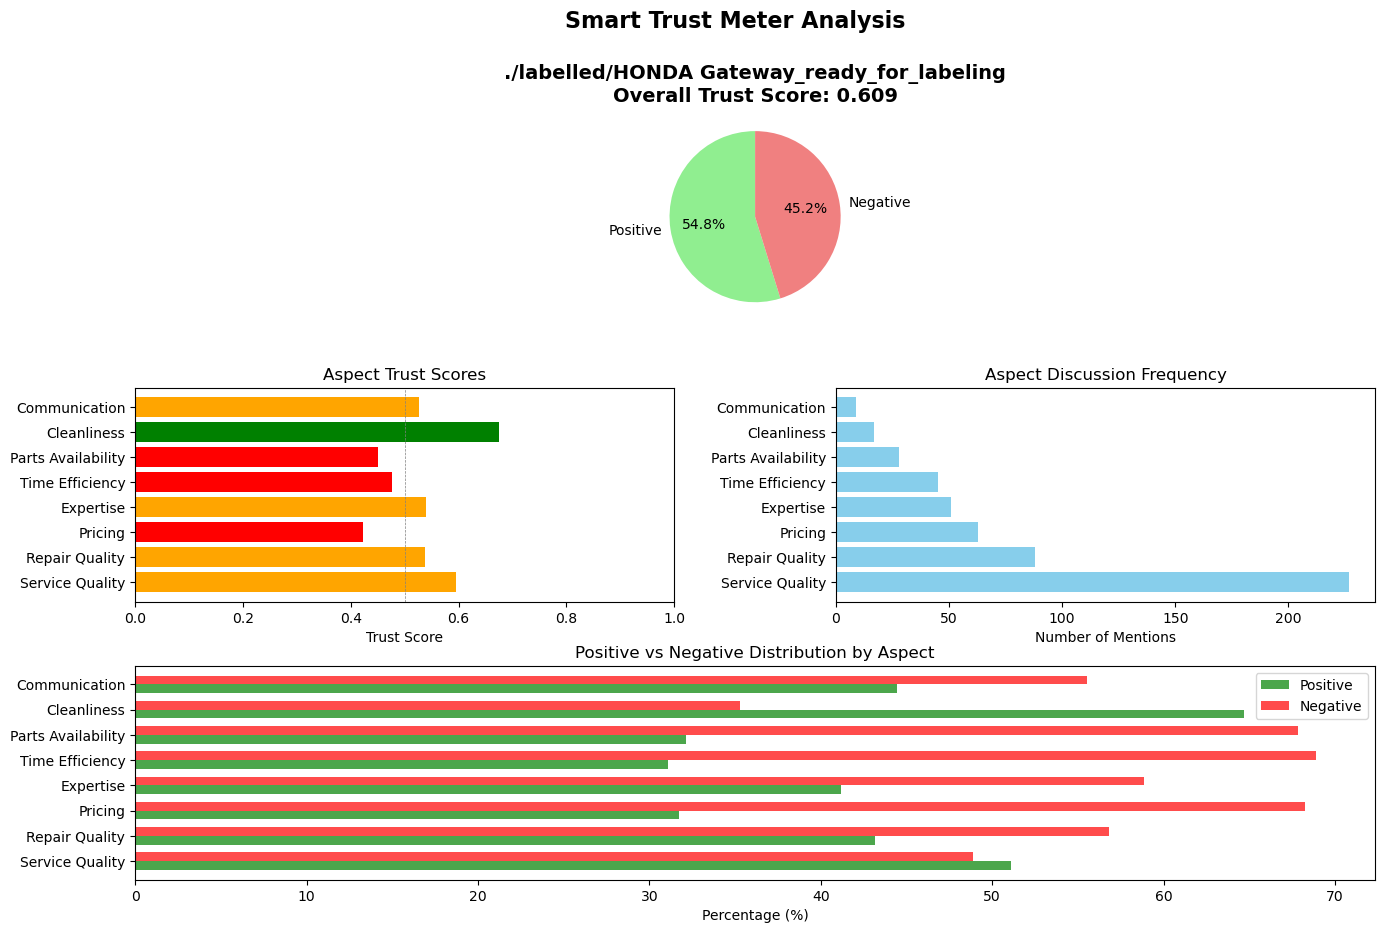

(<__main__.CompleteTrustMeterPipeline at 0x16c315810>,
                                                 wiI7pd dealership_name  \
 0    Its very good workshop and 3S dealership one o...   HONDA Gateway   
 1    A better place for solution of all problems re...   HONDA Gateway   
 2    Honda should cancel their 3S dealership bakwas...   HONDA Gateway   
 3    Not providing Honda spare parts to outsiders e...   HONDA Gateway   
 4                                   3rd Class Services   HONDA Gateway   
 ..                                                 ...             ...   
 351                  Not very professionals, expensive   HONDA Gateway   
 352       3S service provider. Good professional staff   HONDA Gateway   
 353                                   Not fair dealing   HONDA Gateway   
 354                   Good services but too much rush.   HONDA Gateway   
 355              Grate Honda showroom and best service   HONDA Gateway   
 
      manual_label  review_id  predicted_se

In [4]:
analyze_single_dealership("./labelled/HONDA Gateway_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/HONDA Point_ready_for_labeling.csv
Total reviews: 373
Valid reviews: 373

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.529
  Positive reviews: 167 (44.8%)
  Negative reviews: 206 (55.2%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/HONDA Point_ready_for_labeling
Total Reviews Analyzed: 373

OVERALL TRUST SCORE: 0.529/1.00 (Average)

Sentiment Distribution:
  Positive: 167 reviews (44.8%)
  Negative: 206 reviews (55.2%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.526    Average         268        44.4%     
Repair Quality       0.475    Below Average   74         35.1%     
Pricing              0.441    Below Average   71         40.8%     
Time Efficiency      0.456    Below Average   54         35.2%     
Expertise            0.507    Average         54         37.0%     
Parts Availability   0.400    Poor            19         26.3%    

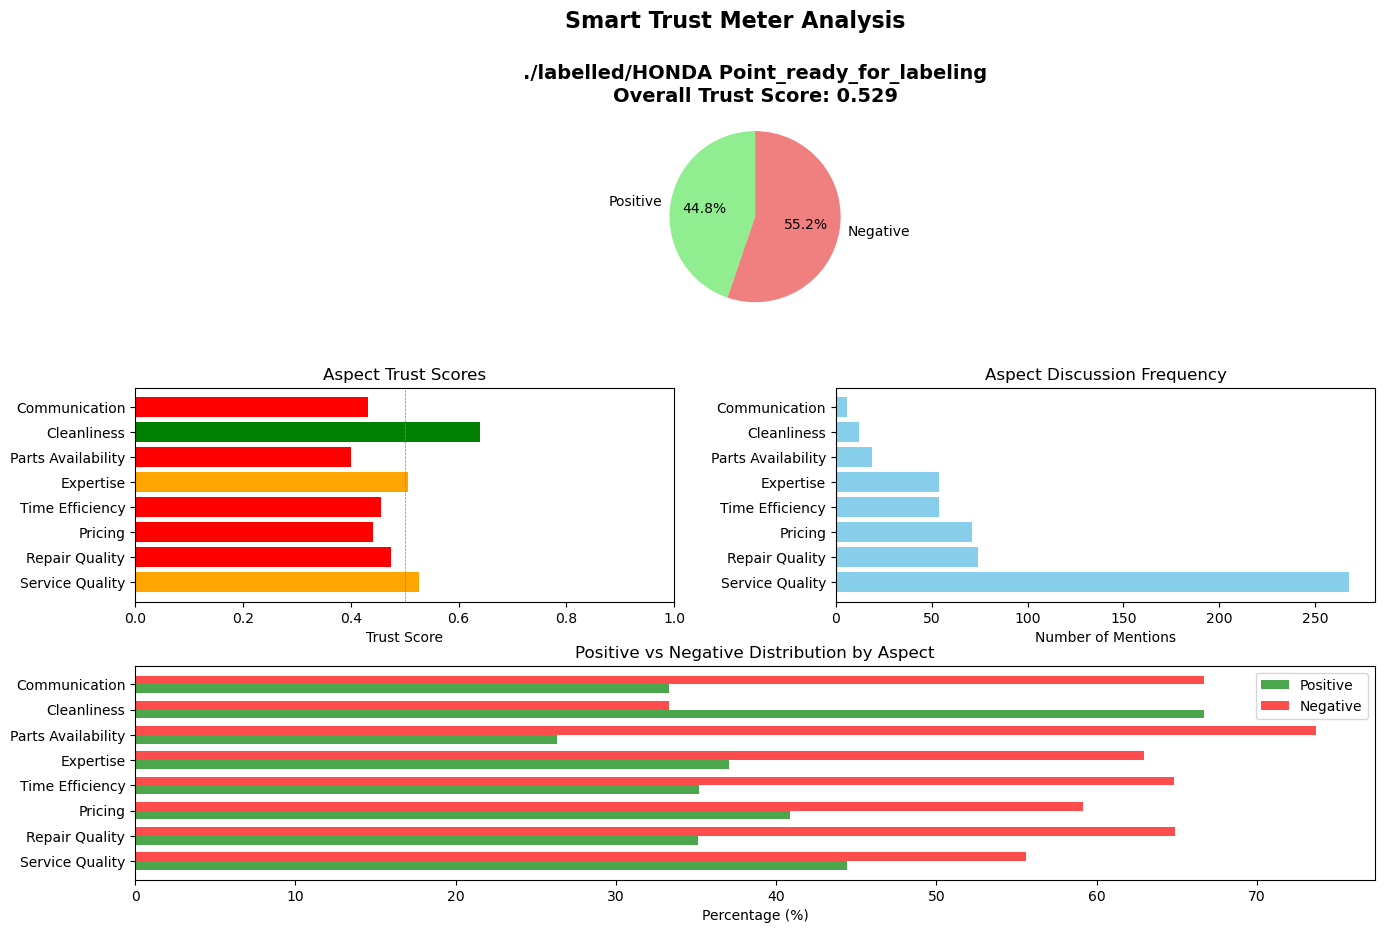

(<__main__.CompleteTrustMeterPipeline at 0x16c314130>,
                                                 wiI7pd dealership_name  \
 0                   Wonderful place, great experience.     HONDA Point   
 1    I have a good experience with Honda point beca...     HONDA Point   
 2                                        Good workshop     HONDA Point   
 3                     Gd gob\nGreat work\nFast service     HONDA Point   
 4    Satisfactory service. Labour charges are throu...     HONDA Point   
 ..                                                 ...             ...   
 368                           Lack of professionalism.     HONDA Point   
 369                                      Not satisfied     HONDA Point   
 370  Eager to sell - but once you have paid - the e...     HONDA Point   
 371  Routine maintenance. my car has been very well...     HONDA Point   
 372                                Cooperative ???? ??     HONDA Point   
 
      manual_label  review_id  predicted_se

In [6]:
analyze_single_dealership("./labelled/HONDA Point_ready_for_labeling.csv")


Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/HONDA RingRoad_ready_for_labeling.csv
Total reviews: 193
Valid reviews: 191

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.707
  Positive reviews: 140 (73.3%)
  Negative reviews: 51 (26.7%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (7 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/HONDA RingRoad_ready_for_labeling
Total Reviews Analyzed: 191

OVERALL TRUST SCORE: 0.707/1.00 (Excellent)

Sentiment Distribution:
  Positive: 140 reviews (73.3%)
  Negative: 51 reviews (26.7%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.739    Excellent       142        77.5%     
Repair Quality       0.640    Good            42         64.3%     
Expertise            0.644    Good            30         66.7%     
Time Efficiency      0.530    Average         19         47.4%     
Cleanliness          0.774    Excellent       11         81.8%     
Pricing              0.425    Below Average   7          42.9%

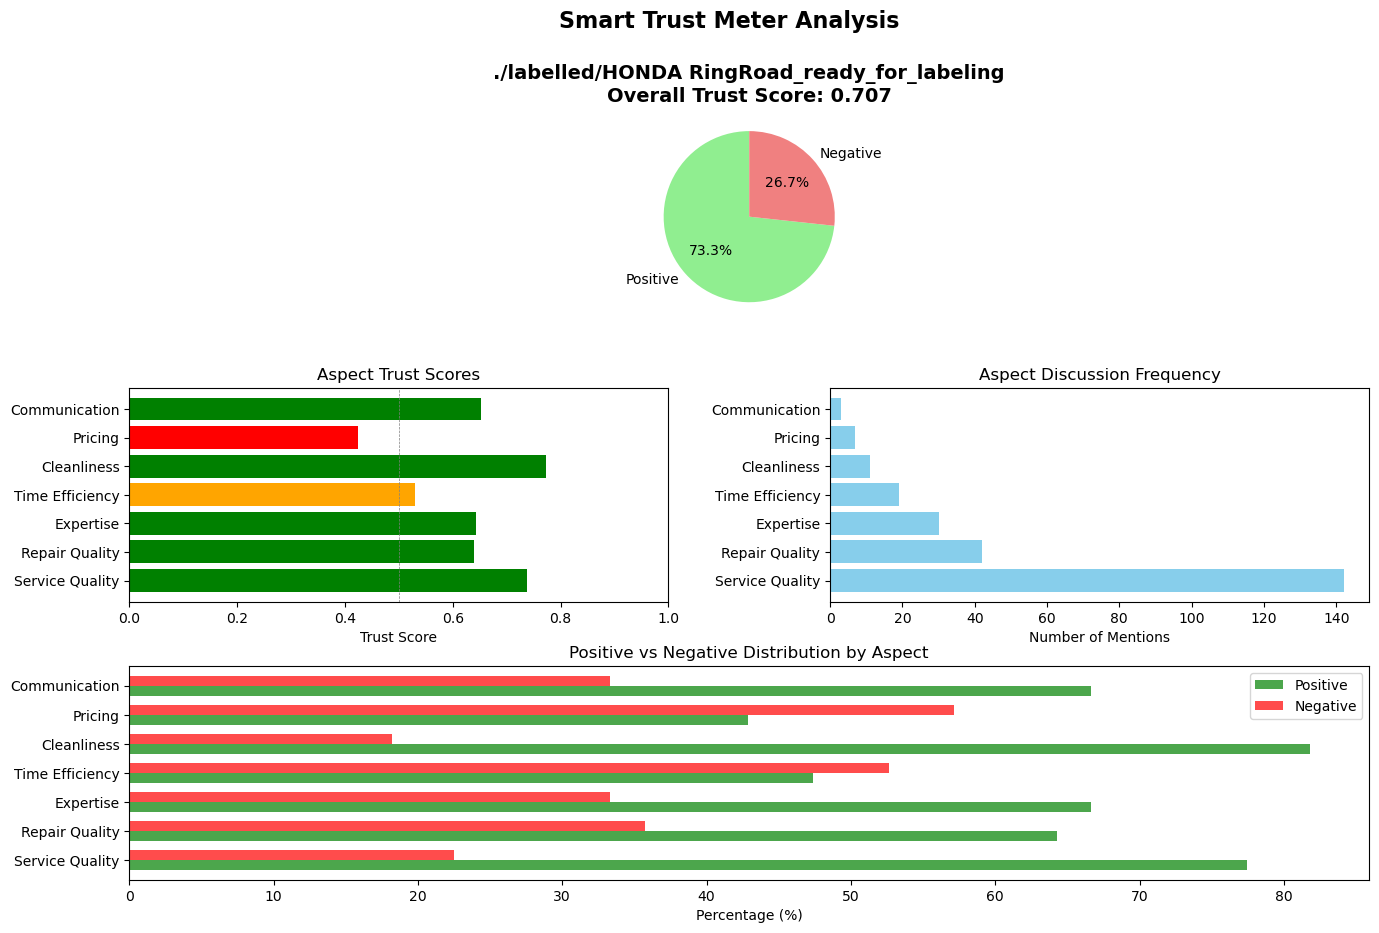

(<__main__.CompleteTrustMeterPipeline at 0x16d428d90>,
                                                 wiI7pd  manual_label  \
 0    Their manners are exceptional...and the comple...           1.0   
 1                 Nice working staff and good services           1.0   
 2    Honda ring road services are just pathetic, ma...           0.0   
 3    Agr oil change k lie ana ho to pehle appointme...           NaN   
 4                 Good services, well experienced team           1.0   
 ..                                                 ...           ...   
 188  Newly established but a bit dangerous road to ...           NaN   
 189          Excellent and very meticulous dealings...           NaN   
 190                                 Highly recommended           NaN   
 191                                      Good Services           NaN   
 192                                Opening coming soon           NaN   
 
     dealership_name  review_id  predicted_sentiment  predicted_lab

In [7]:
analyze_single_dealership("./labelled/HONDA RingRoad_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/HONDA Township_ready_for_labeling.csv
Total reviews: 361
Valid reviews: 360

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.687
  Positive reviews: 247 (68.6%)
  Negative reviews: 113 (31.4%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/HONDA Township_ready_for_labeling
Total Reviews Analyzed: 360

OVERALL TRUST SCORE: 0.687/1.00 (Good)

Sentiment Distribution:
  Positive: 247 reviews (68.6%)
  Negative: 113 reviews (31.4%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.724    Excellent       251        72.9%     
Repair Quality       0.691    Good            75         72.0%     
Expertise            0.613    Good            59         59.3%     
Time Efficiency      0.562    Average         47         53.2%     
Pricing              0.472    Below Average   44         47.7%     
Cleanliness          0.768    Excellent       28         78.6%    

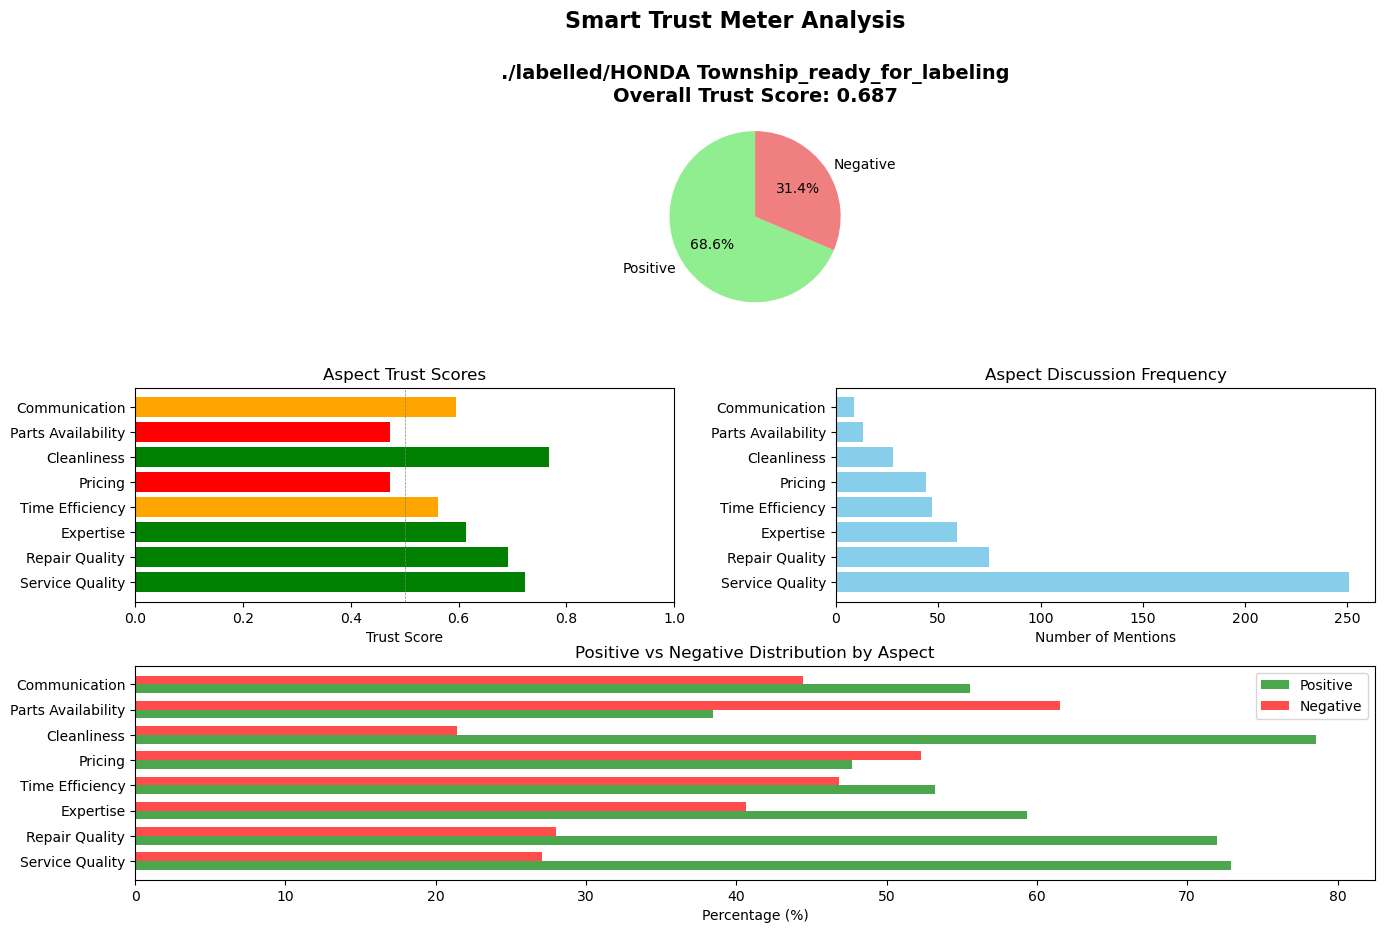

(<__main__.CompleteTrustMeterPipeline at 0x16d831450>,
                                                 wiI7pd dealership_name  \
 0    Good honda center you can purchase the new bra...  HONDA Township   
 1    First time went there, staff was courteous, th...  HONDA Township   
 2                    Alhamdulillah, Lord of the worlds  HONDA Township   
 3                                   Excellent services  HONDA Township   
 4    Professional services with qualified staff. I ...  HONDA Township   
 ..                                                 ...             ...   
 356  Very friendly and professional staff, new dela...  HONDA Township   
 357  I stay under shed of Honda building due to hea...  HONDA Township   
 358  Peaceful ambience, very cooperative staff and ...  HONDA Township   
 359  I highly recommend this dealership. I am reall...  HONDA Township   
 360                   Nice brand with cooprative staff  HONDA Township   
 
      manual_label  review_id  predicted_se

In [8]:
analyze_single_dealership("./labelled/HONDA Township_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/Suzuki Adil Zafar Motors_ready_for_labeling.csv
Total reviews: 249
Valid reviews: 249

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.706
  Positive reviews: 174 (69.9%)
  Negative reviews: 75 (30.1%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/Suzuki Adil Zafar Motors_ready_for_labeling
Total Reviews Analyzed: 249

OVERALL TRUST SCORE: 0.706/1.00 (Excellent)

Sentiment Distribution:
  Positive: 174 reviews (69.9%)
  Negative: 75 reviews (30.1%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.719    Excellent       146        70.5%     
Repair Quality       0.685    Good            53         64.2%     
Pricing              0.541    Average         26         46.2%     
Expertise            0.667    Good            18         66.7%     
Parts Availability   0.606    Good            15         53.3%     
Time Efficiency      0.491    Below Average   13    

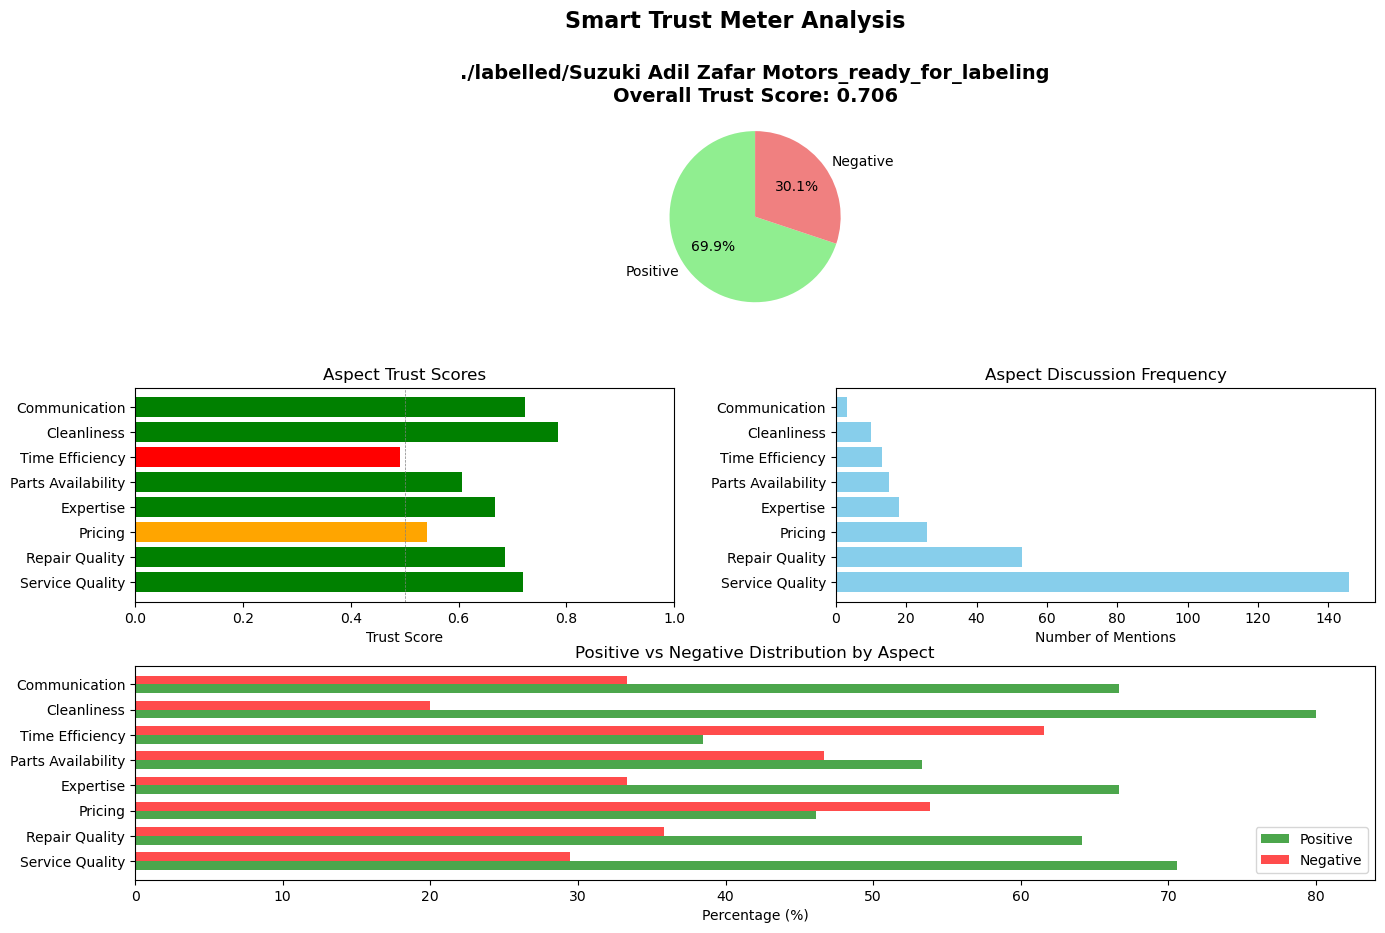

(<__main__.CompleteTrustMeterPipeline at 0x16d831300>,
                                                 wiI7pd  \
 0    Good showroom that offers other services like ...   
 1    Services are OK.. While Spare parts prices are...   
 2    Received vehicle with faults which an ordinary...   
 3    I have been there several times for regular ma...   
 4    They are avoiding to do repairs/services those...   
 ..                                                 ...   
 244                At Multan Road near Hanjarwal stop.   
 245             Main Multan road near hanjarwal Lahore   
 246                            No service for booki ??   
 247                                      Tax bohat  he   
 248  Multan Rd, Muridwal, Hanjarwal, Hanjarwal, Lah...   
 
               dealership_name  manual_label  review_id  predicted_sentiment  \
 0    Suzuki Adil Zafar Motors           1.0          1             0.699596   
 1    Suzuki Adil Zafar Motors           0.0          2             0.52858

In [9]:
analyze_single_dealership("./labelled/Suzuki Adil Zafar Motors_ready_for_labeling.csv")


Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/Suzuki Khalid Motors (Link Ferozpur)_ready_for_labeling.csv
Total reviews: 358
Valid reviews: 358

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.642
  Positive reviews: 214 (59.8%)
  Negative reviews: 144 (40.2%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/Suzuki Khalid Motors (Link Ferozpur)_ready_for_labeling
Total Reviews Analyzed: 358

OVERALL TRUST SCORE: 0.642/1.00 (Good)

Sentiment Distribution:
  Positive: 214 reviews (59.8%)
  Negative: 144 reviews (40.2%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.641    Good            189        58.7%     
Repair Quality       0.627    Good            60         55.0%     
Expertise            0.618    Good            46         52.2%     
Pricing              0.466    Below Average   39         38.5%     
Parts Availability   0.538    Average         24         50.0%     
Time Efficiency      0.493    Below Average 

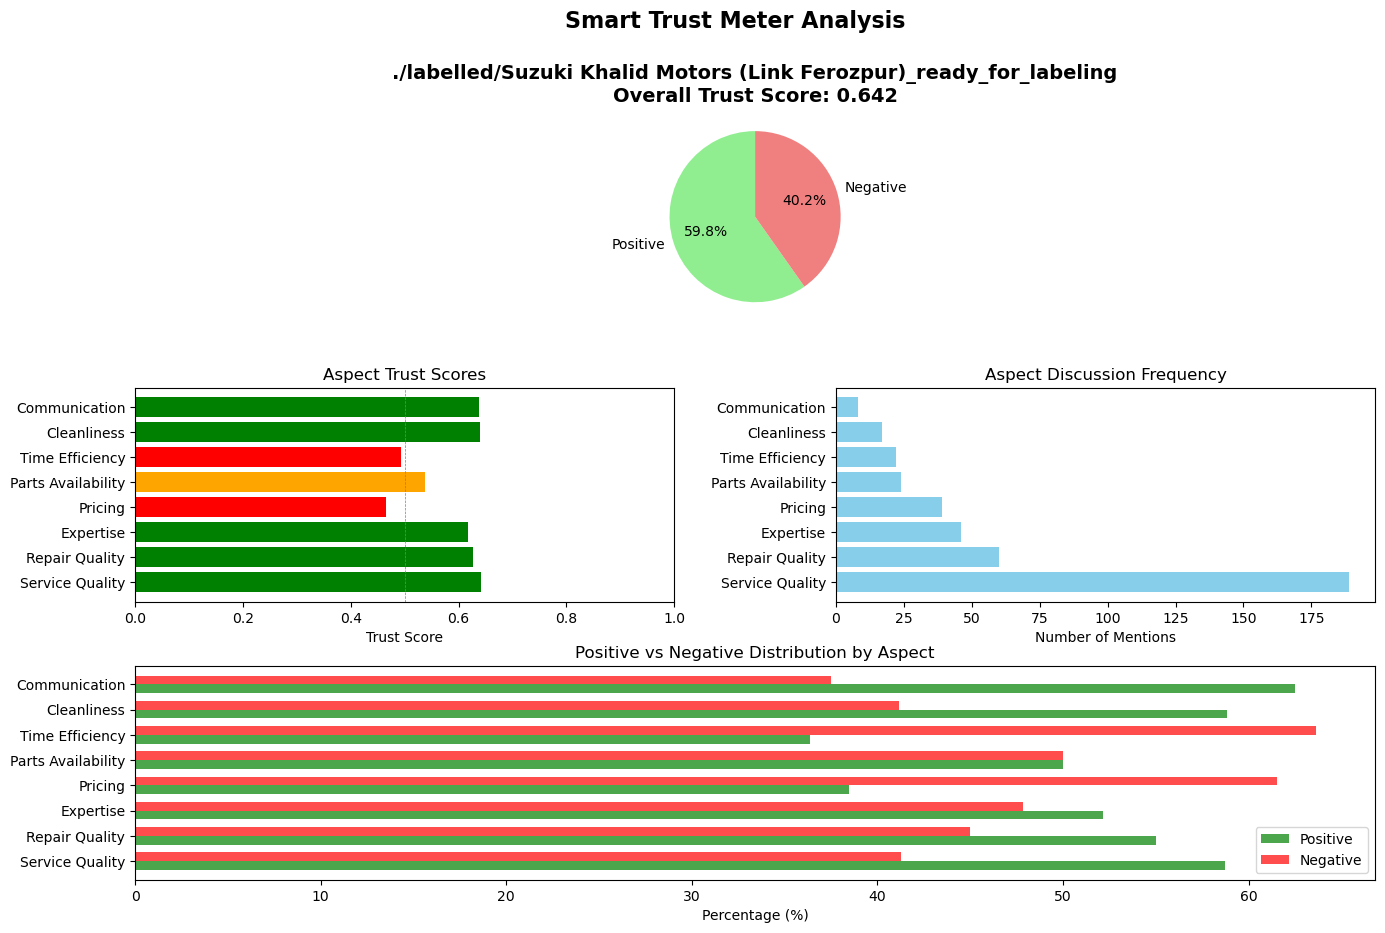

(<__main__.CompleteTrustMeterPipeline at 0x16c990040>,
                                                 wiI7pd  \
 0    When Khalid motor started working, it was amaz...   
 1    On my last visit 3 days ago, the sale  person ...   
 2    Staff isn't very warm .\nThey do ok but hide m...   
 3    Very competent and courteous staff. I've gotte...   
 4    Parking issue and need to enhance the services...   
 ..                                                 ...   
 353                                Boht achi moters hy   
 354                                      Achi jaga hai   
 355                                   Good experienced   
 356                                    Suzuki show pie   
 357                                       Suzuki Motor   
 
                           dealership_name  manual_label  review_id  \
 0    Suzuki Khalid Motors (Link Ferozpur)           0.0          1   
 1    Suzuki Khalid Motors (Link Ferozpur)           0.0          2   
 2    Suzuki Khalid Mo

In [10]:
analyze_single_dealership("./labelled/Suzuki Khalid Motors (Link Ferozpur)_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/Suzuki Mini Motors (Gulberg 3)_ready_for_labeling.csv
Total reviews: 427
Valid reviews: 426

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.688
  Positive reviews: 285 (66.9%)
  Negative reviews: 141 (33.1%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/Suzuki Mini Motors (Gulberg 3)_ready_for_labeling
Total Reviews Analyzed: 426

OVERALL TRUST SCORE: 0.688/1.00 (Good)

Sentiment Distribution:
  Positive: 285 reviews (66.9%)
  Negative: 141 reviews (33.1%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.711    Excellent       257        68.9%     
Repair Quality       0.706    Excellent       99         70.7%     
Expertise            0.683    Good            79         67.1%     
Pricing              0.515    Average         61         50.8%     
Time Efficiency      0.520    Average         26         50.0%     
Parts Availability   0.570    Average         25  

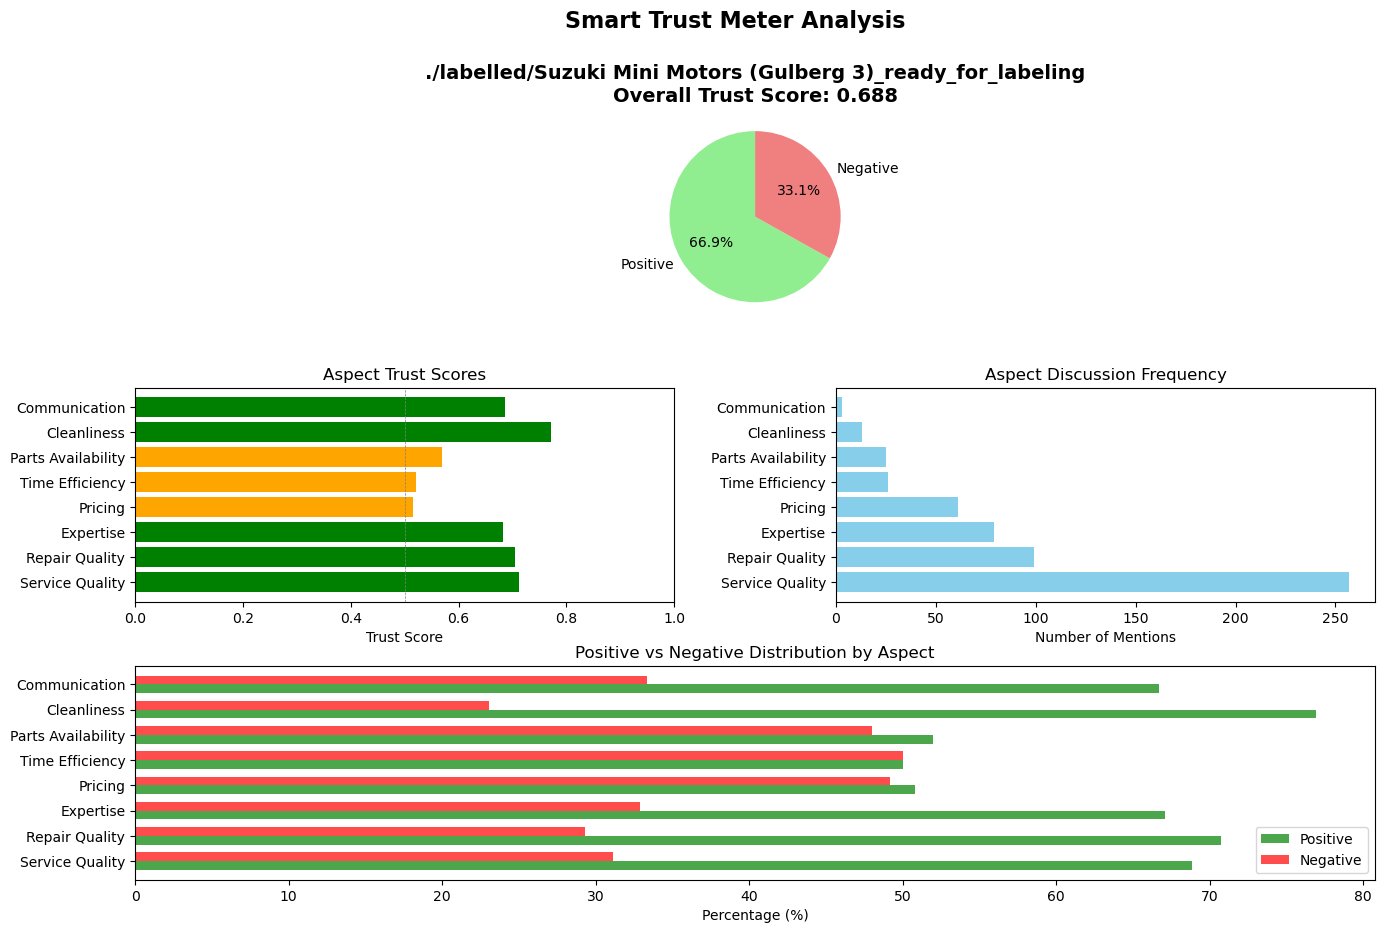

(<__main__.CompleteTrustMeterPipeline at 0x16c3b2bc0>,
                                                 wiI7pd  \
 0    Never visit, save your car.\nWas very good ser...   
 1    Good experience, staff is cooperative. Genuine...   
 2    Always go there for my wagon r service. They m...   
 3    I didn't feel any difference between mini moto...   
 4    Masha'AllaH. Excellent Service & Cooperative S...   
 ..                                                 ...   
 422                                 Suzuki mini motors   
 423  Car ka jo be kaam krwau oski inspection zaroor...   
 424                                        Immediately   
 425                        Assalamu Alaikum\nnice shop   
 426                             Bhout achi ha workshop   
 
                     dealership_name  manual_label  review_id  \
 0    Suzuki Mini Motors (Gulberg 3)           0.0          1   
 1    Suzuki Mini Motors (Gulberg 3)           1.0          2   
 2    Suzuki Mini Motors (Gulberg 3)    

In [11]:
analyze_single_dealership("./labelled/Suzuki Mini Motors (Gulberg 3)_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/Suzuki Sethi Motors (Town Morr)_ready_for_labeling.csv
Total reviews: 645
Valid reviews: 645

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.635
  Positive reviews: 376 (58.3%)
  Negative reviews: 269 (41.7%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/Suzuki Sethi Motors (Town Morr)_ready_for_labeling
Total Reviews Analyzed: 645

OVERALL TRUST SCORE: 0.635/1.00 (Good)

Sentiment Distribution:
  Positive: 376 reviews (58.3%)
  Negative: 269 reviews (41.7%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.631    Good            368        57.1%     
Repair Quality       0.609    Good            172        55.2%     
Time Efficiency      0.445    Below Average   88         33.0%     
Expertise            0.577    Average         65         44.6%     
Pricing              0.393    Poor            63         27.0%     
Parts Availability   0.496    Below Average   31 

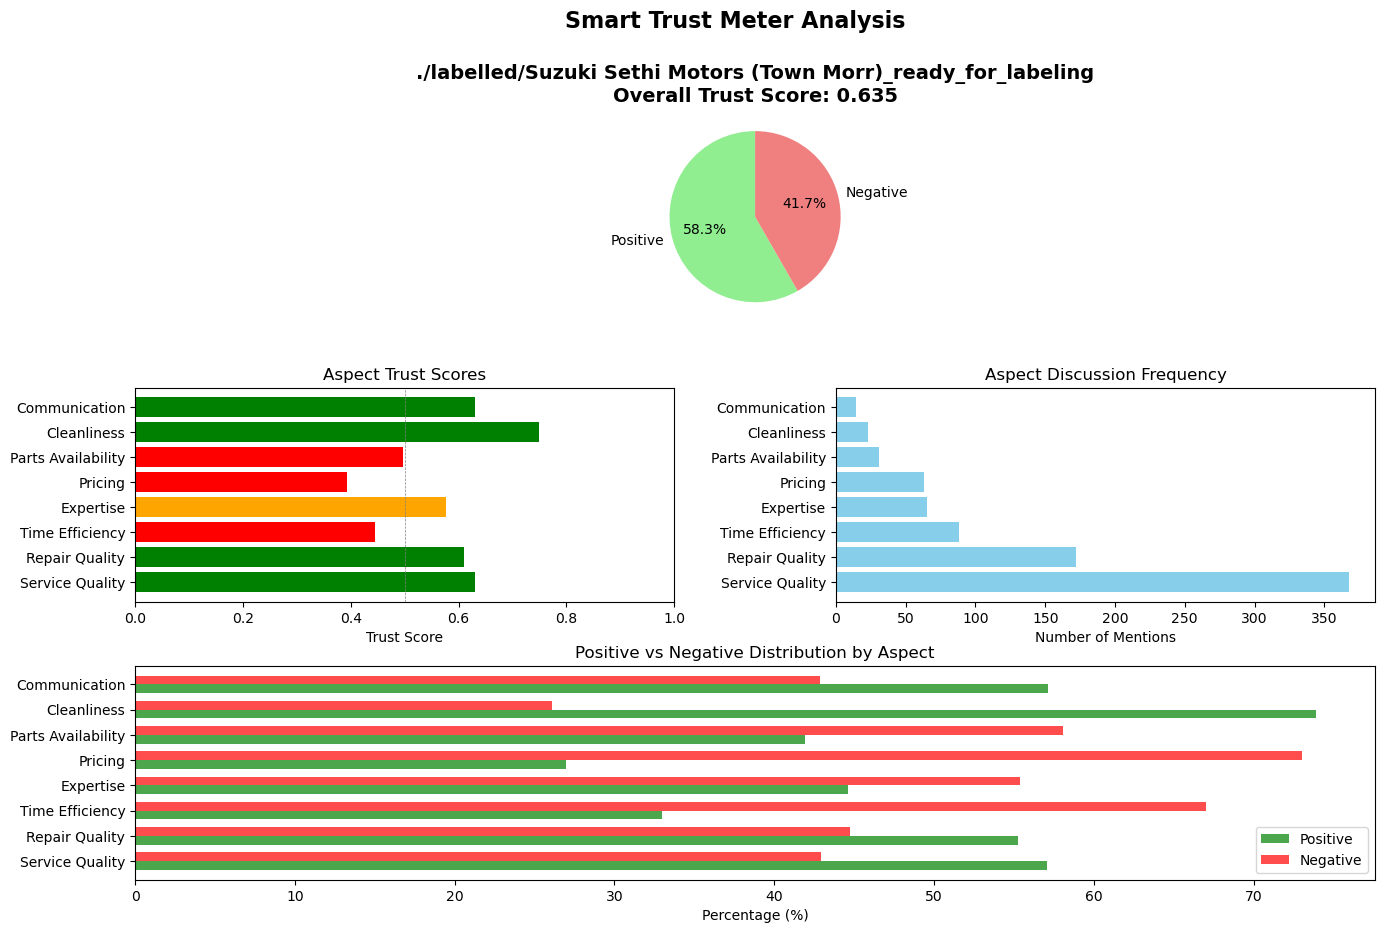

(<__main__.CompleteTrustMeterPipeline at 0x16db600d0>,
                                                 wiI7pd  \
 0    Suzuki Sethi Motors, proud to be among the lea...   
 1    I have experience in changing oil, plus I have...   
 2    A good experience of maintenance job of my car...   
 3    Done AC service from sethi motors, staff is fr...   
 4    This is an expensive place with no customer ca...   
 ..                                                 ...   
 640                                     God department   
 641                                     Throw them out   
 642                                        NAIC points   
 643                                     Fazool service   
 644                                        Masha Allah   
 
                      dealership_name  manual_label  review_id  \
 0    Suzuki Sethi Motors (Town Morr)           1.0          1   
 1    Suzuki Sethi Motors (Town Morr)           1.0          2   
 2    Suzuki Sethi Motors (Town Morr)

In [12]:
analyze_single_dealership("./labelled/Suzuki Sethi Motors (Town Morr)_ready_for_labeling.csv")

Loading trained model...
Model loaded successfully!

ANALYZING: ./labelled/Suzuki_Raiwind_Motors(Raiwind Rd)_ready_for_labeling.csv
Total reviews: 291
Valid reviews: 262

[1/3] Predicting sentiment for all reviews...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Complete
  Overall Trust Score: 0.570
  Positive reviews: 134 (51.1%)
  Negative reviews: 128 (48.9%)

[2/3] Extracting aspect-level insights...


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/tf-env/lib/pyth

Complete (8 aspects found)

[3/3] Generating report...

SMART TRUST METER REPORT
Dealership: ./labelled/Suzuki_Raiwind_Motors(Raiwind Rd)_ready_for_labeling
Total Reviews Analyzed: 262

OVERALL TRUST SCORE: 0.570/1.00 (Average)

Sentiment Distribution:
  Positive: 134 reviews (51.1%)
  Negative: 128 reviews (48.9%)

----------------------------------------------------------------------
ASPECT ANALYSIS
----------------------------------------------------------------------

Aspect               Score    Rating          Mentions   Positive  
----------------------------------------------------------------------
Service Quality      0.583    Average         150        51.3%     
Repair Quality       0.387    Poor            41         22.0%     
Expertise            0.501    Average         33         30.3%     
Pricing              0.359    Poor            28         25.0%     
Time Efficiency      0.440    Below Average   24         29.2%     
Parts Availability   0.437    Below Average 

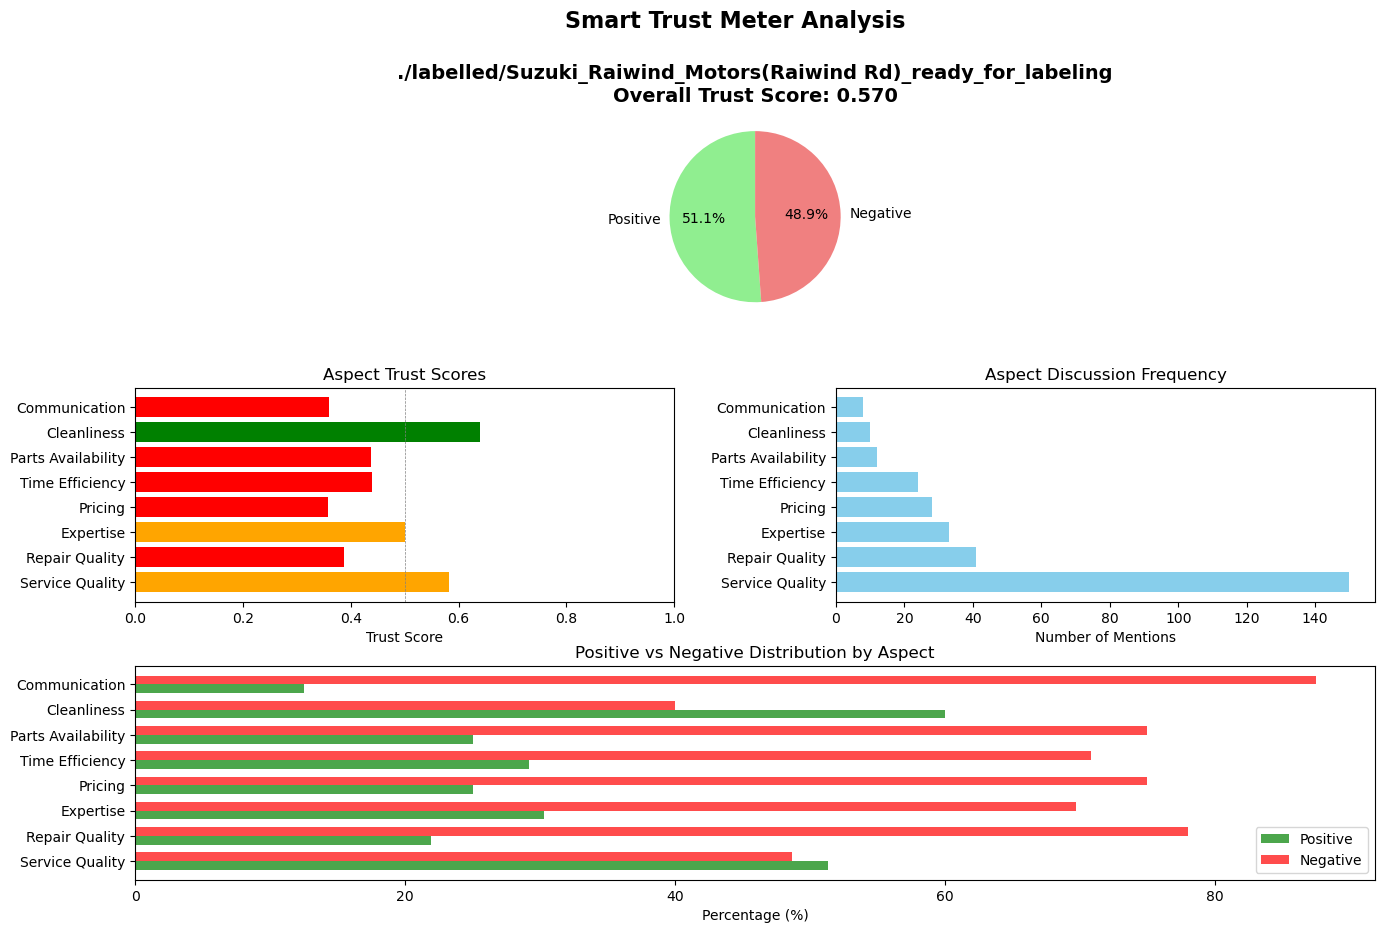

(<__main__.CompleteTrustMeterPipeline at 0x16df98940>,
                                                 wiI7pd  \
 0                                   Experienced staff.   
 1    This time most bad experience of all time in a...   
 2    I buy 6500 package of tunning.the worker waste...   
 3    I do not want to give single star as well. In ...   
 4    How they are good in service ? even they are n...   
 ..                                                 ...   
 286                     Good and cooperative all staff   
 287  Wasn't expecting such great service and custom...   
 288                                     Suzuki Raiwind   
 289  No proper guidance to customer.Suzuki staff is...   
 290                                    Good experience   
 
                         dealership_name  manual_label  review_id  \
 0    Suzuki Raiwind Motors (Raiwind Rd)           1.0          1   
 1    Suzuki Raiwind Motors (Raiwind Rd)           0.0          2   
 2    Suzuki Raiwind Motors 

In [13]:
analyze_single_dealership("./labelled/Suzuki_Raiwind_Motors(Raiwind Rd)_ready_for_labeling.csv")